# TravelTide Mastery Project

## Kundensegmentierung und Perk-Zuweisung

### Ziel des Notebooks

In diesem Notebook werden die im Rahmen der Datenaufbereitung entwickelten Kundenmerkmale genutzt, um Kunden mit ähnlichem Reise-, Buchungs- und Nutzungsverhalten zu identifizieren.

Hierfür werden zunächst geeignete Merkmale für die Segmentierung ausgewählt und vorbereitet. Anschließend werden verschiedene Verfahren zur Kundensegmentierung untersucht:

- K-Means-Clustering
- DBSCAN
- Dimensionsreduktion mit PCA

Die Ergebnisse der Verfahren werden anhand geeigneter Kennzahlen sowie ihrer inhaltlichen Interpretierbarkeit verglichen. Auf Grundlage der finalen Kundensegmente werden die charakteristischen Verhaltensweisen der einzelnen Gruppen beschrieben und verständliche Segmentbezeichnungen entwickelt.

Abschließend wird jedem Kunden ein voraussichtlich passender Benefit aus dem geplanten TravelTide-Rewards-Programm zugeordnet:

- kostenlose Hotelmahlzeit
- kostenloses Aufgabegepäck
- keine Stornierungsgebühren
- exklusive Rabatte
- kostenlose Hotelnacht bei gemeinsamer Flug- und Hotelbuchung

Das Ergebnis ist eine finale Kundentabelle, die neben den aufbereiteten Kundenmerkmalen auch die Segmentzugehörigkeit und den empfohlenen Benefit enthält.

## 1. Datenimport und erste Datenprüfung

Zunächst wird die in Notebook 01 erstellte finale Kundentabelle eingelesen. Sie enthält pro Kunde genau eine Zeile sowie die aufbereiteten demografischen, verhaltensbezogenen und monetären Merkmale.

Vor der Segmentierung werden die Dimensionen der Tabelle, die Eindeutigkeit der Nutzer, die Datentypen sowie die vorhandenen Spalten überprüft. Dadurch wird sichergestellt, dass die Daten vollständig und in der erwarteten Struktur vorliegen.

In [1]:
# Bibliotheken importieren

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid")

In [2]:
# Finale Kundentabelle aus der Datenaufbereitung einlesen

customer_features = pd.read_csv(
    "../data/processed/customer_features.csv"
)

print(f"Zeilen: {customer_features.shape[0]}")
print(f"Spalten: {customer_features.shape[1]}")

display(customer_features.head())

Zeilen: 5752
Spalten: 79


,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age,customer_tenure_days,customer_tenure_months,session_count,mean_session_duration_minutes,median_session_duration_minutes,total_page_clicks,mean_page_clicks,low_click_session_rate,booking_session_count,flight_booking_session_count,hotel_booking_session_count,package_booking_session_count,cancellation_count,flight_discount_offer_count,hotel_discount_offer_count,mean_flight_discount_amount,mean_hotel_discount_amount,discounted_flight_booking_count,discounted_hotel_booking_count,booking_session_rate,cancellation_session_rate,package_booking_rate,flight_discount_conversion_rate,hotel_discount_conversion_rate,flight_booking_count,total_flight_value_before_discount_usd,total_flight_value_after_discount_usd,total_realized_flight_spend_usd,mean_flight_booking_value_after_discount_usd,total_seats,mean_seats,total_checked_bags,mean_checked_bags,mean_fare_per_seat_after_discount_usd,return_flight_rate,cancelled_flight_count,weighted_fare_per_seat_after_discount_usd,hotel_booking_count,total_hotel_value_before_discount_usd,mean_hotel_value_before_discount_usd,total_hotel_value_after_discount_usd,mean_hotel_value_after_discount_usd,total_realized_hotel_spend_usd,mean_completed_hotel_spend_usd,total_hotel_nights,mean_hotel_nights,total_rooms,mean_rooms,mean_hotel_price_per_room_usd,median_hotel_price_per_room_usd,unique_hotel_brands,unique_hotel_cities,extended_stay_booking_count,extended_stay_booking_share,cancelled_hotel_count,preferred_hotel_segment,preferred_hotel_city,hotel_price_tier_share_Low price,hotel_price_tier_share_Medium price,hotel_price_tier_share_High price,hotel_price_tier_share_Very high price,has_flight_booking,has_hotel_booking,has_travel_booking,checked_bags_per_seat,total_cancelled_bookings,historical_customer_value_usd
0,23557,1958-12-08,F,True,False,usa,new york,LGA,40.777,-73.872,2021-07-22,64,736,24.179,8,1.277,1.158,82,10.250,0.000,2,0,2,0,0,0,2,NaN,0.175,0,1,0.250,0.000,0.000,NaN,0.500,0.000,0.000,0.000,0.000,NaN,0.000,NaN,0.000,NaN,NaN,NaN,0.000,NaN,2.000,"3,802.000","1,901.000","3,670.500","1,835.250","3,670.500","1,835.250",20.000,10.000,3.000,1.500,177.000,177.000,2.000,2.000,1.000,0.500,0.000,Economy,Calgary,0.500,0.000,0.000,0.500,False,True,True,0.000,0.000,"3,670.500"
1,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,51,536,17.608,8,1.129,0.625,73,9.125,0.000,2,2,2,2,0,0,1,NaN,0.100,0,0,0.250,0.000,1.000,NaN,0.000,2.000,864.090,864.090,864.090,432.045,3.000,1.500,1.000,0.500,276.252,1.000,0.000,288.030,2.000,230.000,115.000,230.000,115.000,230.000,115.000,2.000,1.000,3.000,1.500,90.000,90.000,2.000,2.000,0.000,0.000,0.000,Luxury,Jacksonville,0.500,0.500,0.000,0.000,True,True,True,0.333,0.000,"1,094.090"
2,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,50,526,17.280,8,2.038,2.433,131,16.375,0.000,2,1,2,1,0,2,0,0.075,NaN,0,0,0.250,0.000,0.500,0.000,NaN,1.000,189.910,189.910,189.910,189.910,1.000,1.000,0.000,0.000,189.910,1.000,0.000,189.910,2.000,"2,199.000","1,099.500","2,199.000","1,099.500","2,199.000","1,099.500",8.000,4.000,3.000,1.500,198.500,198.500,2.000,2.000,0.000,0.000,0.000,Luxury,Edmonton,0.000,0.500,0.000,0.500,True,True,True,0.000,0.000,"2,388.910"
3,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17,42,526,17.280,8,1.962,2.217,126,15.750,0.125,5,5,5,5,0,2,1,0.150,0.100,1,0,0.625,0.000,1.000,0.500,0.000,5.000,"1,242.660","1,237.693","1,237.693",247.539,5.000,1.000,2.000,0.400,247.539,1.000,0.000,247.539,5.000,"2,429.000",485.800,"2,429.000",485.800,"2,429.000",485.800,19.000,3.800,5.000,1.000,136.000,132.000,5.000,5.000,1.000,0.200,0.000,Luxury,Charlotte,0.200,0.400,0.400,0.000,True,True,True,0.400,0.000,"3,666.693"
4,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24,44,519,17.050,8,12.649,2.392,240,30.000,0.000,1,1,1,1,1,1,1,NaN,NaN,0,0,0.125,0.125,1.000,0.000,0.000,1.

In [3]:
# Struktur und Datentypen prüfen

customer_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 5752 entries, 0 to 5751
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   user_id                                       5752 non-null   int64  
 1   birthdate                                     5752 non-null   str    
 2   gender                                        5752 non-null   str    
 3   married                                       5752 non-null   bool   
 4   has_children                                  5752 non-null   bool   
 5   home_country                                  5752 non-null   str    
 6   home_city                                     5752 non-null   str    
 7   home_airport                                  5752 non-null   str    
 8   home_airport_lat                              5752 non-null   float64
 9   home_airport_lon                              5752 non-null   float64
 10 

In [4]:
# Anzahl eindeutiger Kunden prüfen

print(
    "Eindeutige Nutzer:",
    customer_features["user_id"].nunique()
)

print(
    "Doppelte Nutzer:",
    customer_features["user_id"].duplicated().sum()
)

Eindeutige Nutzer: 5752
Doppelte Nutzer: 0


In [5]:
# Alle vorhandenen Spalten (= Merkmale) übersichtlich anzeigen.

columns_overview = pd.DataFrame({
    "column": customer_features.columns,
    "dtype": customer_features.dtypes.astype(str).values,
    "missing_values": customer_features.isna().sum().values,
    "unique_values": customer_features.nunique(dropna=False).values
})

display(columns_overview)

,column,dtype,missing_values,unique_values
0,user_id,int64,0,5752
1,birthdate,str,0,4625
2,gender,str,0,3
3,married,bool,0,2
4,has_children,bool,0,2
5,home_country,str,0,2
6,home_city,str,0,105
7,home_airport,str,0,159
8,home_airport_lat,float64,0,158
9,home_airport_lon,float64,0,158


In [6]:
# Numerische und nicht-numerische Spalten unterscheiden, da nicht-numerische Spalten u.a. vor der Nutzung 
# von K-Means noch in numerische Spalten umgewandelt werden müssen.

numeric_columns = customer_features.select_dtypes(
    include="number"
).columns.tolist()

non_numeric_columns = customer_features.select_dtypes(
    exclude="number"
).columns.tolist()

print("Numerische Spalten:")
display(numeric_columns)

print("\nNicht numerische Spalten:")
display(non_numeric_columns)

Numerische Spalten:


['user_id',
 'home_airport_lat',
 'home_airport_lon',
 'age',
 'customer_tenure_days',
 'customer_tenure_months',
 'session_count',
 'mean_session_duration_minutes',
 'median_session_duration_minutes',
 'total_page_clicks',
 'mean_page_clicks',
 'low_click_session_rate',
 'booking_session_count',
 'flight_booking_session_count',
 'hotel_booking_session_count',
 'package_booking_session_count',
 'cancellation_count',
 'flight_discount_offer_count',
 'hotel_discount_offer_count',
 'mean_flight_discount_amount',
 'mean_hotel_discount_amount',
 'discounted_flight_booking_count',
 'discounted_hotel_booking_count',
 'booking_session_rate',
 'cancellation_session_rate',
 'package_booking_rate',
 'flight_discount_conversion_rate',
 'hotel_discount_conversion_rate',
 'flight_booking_count',
 'total_flight_value_before_discount_usd',
 'total_flight_value_after_discount_usd',
 'total_realized_flight_spend_usd',
 'mean_flight_booking_value_after_discount_usd',
 'total_seats',
 'mean_seats',
 'tota


Nicht numerische Spalten:


['birthdate',
 'gender',
 'married',
 'has_children',
 'home_country',
 'home_city',
 'home_airport',
 'sign_up_date',
 'preferred_hotel_segment',
 'preferred_hotel_city',
 'has_flight_booking',
 'has_hotel_booking',
 'has_travel_booking']

## 2. Regelbasierte Kundensegmentierung

Im ersten Schritt werden Kunden mit besonders klaren und geschäftlich relevanten Eigenschaften regelbasiert segmentiert. Dazu werden sowohl Verhaltensmerkmale als auch ausgewählte demografische Informationen verwendet.

### Definition der regelbasierten Kundengruppen

Für die regelbasierte Segmentierung werden sechs Kundengruppen definiert, die sich durch besonders klar erkennbare und geschäftlich relevante Verhaltensweisen auszeichnen.

Die Regeln basieren auf den zuvor entwickelten Kundenmerkmalen und kombinieren monetäre, buchungsbezogene sowie ausgewählte demografische Informationen.

| Gruppe | Kerngedanke | Regel |
|---|---|---|
| **High-Value Bookers** | Kunden mit einem besonders hohen bisher realisierten Kundenwert | `historical_customer_value_usd` liegt innerhalb der obersten 10 % |
| **Family Travelers** | Kunden, die Kinder haben und mit mehreren Personen reisen | Kinder vorhanden und durchschnittlich mindestens 1,8 gebuchte Sitzplätze |
| **Long-Stay Hotel Guests** | Kunden mit überdurchschnittlich langen Hotelaufenthalten | durchschnittlich mindestens 7 Hotelnächte je Buchung |
| **Discount-Responsive Travelers** | Kunden, die nachweislich häufig auf Rabattangebote reagieren | mindestens 2 Rabattangebote erhalten und mindestens 50 % davon genutzt |
| **Baggage-Intensive Flyers** | regelmäßige Flugkunden mit einer hohen Nutzung von Aufgabegepäck | mindestens 2 Flugbuchungen und durchschnittlich mindestens 0,75 Gepäckstücke je Sitzplatz |
| **Cancellation-Experienced Travelers** | Kunden mit bisheriger Stornierungserfahrung | mindestens eine stornierte Flug- oder Hotelbuchung |

Die Gruppen wurden so gewählt, dass sie anhand beobachtbarer Merkmale nachvollziehbar, für die spätere Entwicklung von Benefits relevant und ausreichend spezifisch sind.

Die Regeln müssen nicht gegenseitig exklusiv sein. Ein Kunde kann beispielsweise gleichzeitig einen hohen Kundenwert besitzen, häufig Rabattangebote nutzen und mit viel Aufgabegepäck reisen. Deshalb werden zunächst separate Indikatoren für alle erfüllten Regeln gespeichert.  Erst auf dieser Grundlage wird eine Prioritätsreihenfolge für die eindeutige Segmentzuordnung festgelegt, um ein primäres Segment vergeben.

Kunden, die keine der Regeln erfüllen, werden nicht künstlich einer Gruppe zugeordnet. Sie werden im anschließenden Clustering datengetrieben weiter segmentiert.

In [7]:
# Benötigte Kennzahlen vorbereiten

customer_features["total_discount_offer_count"] = (
    customer_features["flight_discount_offer_count"]
    + customer_features["hotel_discount_offer_count"]
)

customer_features["total_discounted_booking_count"] = (
    customer_features["discounted_flight_booking_count"]
    + customer_features["discounted_hotel_booking_count"]
)

customer_features["booking_discount_rate"] = np.where(
    customer_features["total_discount_offer_count"] > 0,
    (
        customer_features["total_discounted_booking_count"]
        / customer_features["total_discount_offer_count"]
    ),
    np.nan
)

In [8]:
# Grenzwert für Top Spenders berechnen.

high_value_threshold = (
    customer_features[
        "historical_customer_value_usd"
    ]
    .quantile(0.90)
)

print(
    "Grenzwert für High-Value Bookers:",
    round(high_value_threshold, 2),
    "USD"
)

Grenzwert für High-Value Bookers: 5799.32 USD


In [9]:
# Eigene Regel-Flags erstellen

rule_flags = pd.DataFrame({
    "user_id": customer_features["user_id"],

    # Oberste 10 % nach bisher realisiertem Kundenwert
    "high_value_booker": (
        customer_features["historical_customer_value_usd"]
        >= high_value_threshold
    ),

    # Kunden mit Kindern und mehreren gebuchten Sitzplätzen
    "family_traveler": (
        (customer_features["has_children"] == True)
        & (customer_features["mean_seats"] >= 1.80)
    ),

    # Durchschnittlich mindestens sieben Hotelnächte
    "long_stay_hotel_guest": (
        customer_features["mean_hotel_nights"] >= 7
    ),

    # Mindestens zwei Angebote erhalten und mindestens die Hälfte genutzt
    "discount_responsive_traveler": (
        (customer_features["total_discount_offer_count"] >= 2)
        & (customer_features["booking_discount_rate"] >= 0.50)
    ),

    # Wiederholte Flugbuchungen mit relativ viel Aufgabegepäck
    "baggage_intensive_flyer": (
        (customer_features["flight_booking_count"] >= 2)
        & (customer_features["checked_bags_per_seat"] >= 0.75)
    ),

    # Mindestens eine stornierte Flug- oder Hotelbuchung
    "cancellation_experienced_traveler": (
        customer_features["total_cancelled_bookings"] >= 1
    )
})

In [10]:
# Fehlende Vergleiche behandeln

rule_columns = [
    "high_value_booker",
    "family_traveler",
    "long_stay_hotel_guest",
    "discount_responsive_traveler",
    "baggage_intensive_flyer",
    "cancellation_experienced_traveler"
]

rule_flags[rule_columns] = (
    rule_flags[rule_columns]
    .fillna(False)
    .astype(bool)
)

In [11]:
# Gruppengrößen prüfen

rule_summary = pd.DataFrame({
    "customer_count": (
        rule_flags[rule_columns]
        .sum()
    ),
    "customer_share_percent": (
        rule_flags[rule_columns]
        .mean()
        * 100
    )
}).sort_values(
    "customer_count",
    ascending=False
)

display(rule_summary)

,customer_count,customer_share_percent
discount_responsive_traveler,1181,20.532
baggage_intensive_flyer,861,14.969
long_stay_hotel_guest,596,10.362
high_value_booker,576,10.014
cancellation_experienced_traveler,562,9.771
family_traveler,182,3.164


In [12]:
# Zahl erfüllter Regeln prüfen

rule_flags["matched_rule_count"] = (
    rule_flags[rule_columns]
    .sum(axis=1)
)

rule_count_summary = (
    rule_flags["matched_rule_count"]
    .value_counts()
    .sort_index()
    .rename("customer_count")
    .to_frame()
)

rule_count_summary["customer_share_percent"] = (
    rule_count_summary["customer_count"]
    / len(rule_flags)
    * 100
)

display(rule_count_summary)

,customer_count,customer_share_percent
matched_rule_count,,
0,2817,48.974
1,2083,36.213
2,702,12.204
3,131,2.277
4,17,0.296
5,2,0.035


,high_value_booker,family_traveler,long_stay_hotel_guest,discount_responsive_traveler,baggage_intensive_flyer,cancellation_experienced_traveler
high_value_booker,576,42,150,188,91,20
family_traveler,42,182,38,32,28,58
long_stay_hotel_guest,150,38,596,74,49,99
discount_responsive_traveler,188,32,74,1181,227,34
baggage_intensive_flyer,91,28,49,227,861,87
cancellation_experienced_traveler,20,58,99,34,87,562


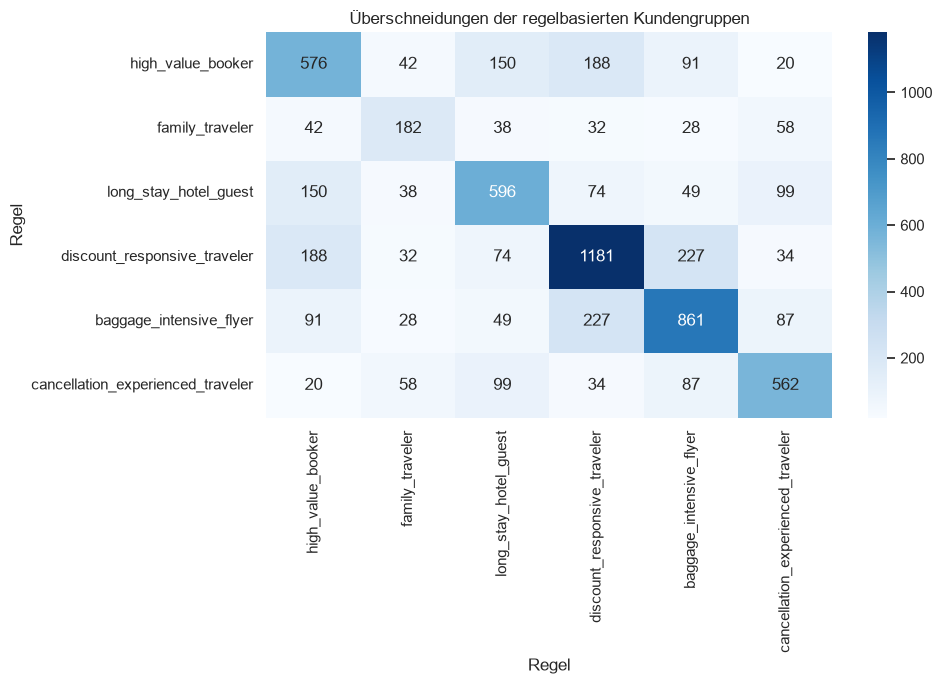

In [13]:
# Überschneidungen prüfen

overlap_matrix = (
    rule_flags[rule_columns]
    .astype(int)
    .T
    .dot(
        rule_flags[rule_columns]
        .astype(int)
    )
)

display(overlap_matrix)

plt.figure(figsize=(10, 7))

sns.heatmap(
    overlap_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Überschneidungen der regelbasierten Kundengruppen"
)

plt.xlabel("Regel")
plt.ylabel("Regel")
plt.tight_layout()
plt.show()

In [14]:
# Verbleibende Kunden bestimmen

unassigned_rule_mask = (
    rule_flags["matched_rule_count"] == 0
)

print(
    "Mindestens einer Regel zugeordnet:",
    (~unassigned_rule_mask).sum()
)

print(
    "Noch nicht zugeordnet:",
    unassigned_rule_mask.sum()
)

print(
    "Anteil noch nicht zugeordnet:",
    round(
        unassigned_rule_mask.mean() * 100,
        2
    ),
    "%"
)

Mindestens einer Regel zugeordnet: 2935
Noch nicht zugeordnet: 2817
Anteil noch nicht zugeordnet: 48.97 %


In [15]:
# Eindeutig regelbasierte Kundensegmente erstellen.

customer_segments = (
    customer_features
    .merge(
        rule_flags[
            ["user_id"]
            + rule_columns
            + ["matched_rule_count"]
        ],
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

### Priorisierung überschneidender Regeln

Da einige Kunden mehrere Regeln gleichzeitig erfüllen, wird für die finale Segmentzuordnung eine Prioritätsreihenfolge festgelegt. Dabei werden spezifische Reisebedürfnisse vor allgemeineren Wertmerkmalen priorisiert:

1. Family Travelers
2. Long-Stay Hotel Guests
3. Baggage-Intensive Flyers
4. Discount-Responsive Travelers
5. Cancellation-Experienced Travelers
6. High-Value Bookers

Ein hoher Kundenwert wird in dieser Reihenfolge zuletzt berücksichtigt, da er die wirtschaftliche Bedeutung eines Kunden beschreibt, aber nicht unmittelbar dessen konkretes Reisebedürfnis. Das zusätzliche `high_value_booker`-Flag bleibt unabhängig vom primären Segment erhalten. Dadurch können besonders wertvolle Kunden auch innerhalb der übrigen Reisegruppen identifiziert werden.

In [16]:
# Prioritätsreihenfolge der regelbasierten Segmente

priority_conditions = [
    customer_segments["family_traveler"],
    customer_segments["long_stay_hotel_guest"],
    customer_segments["baggage_intensive_flyer"],
    customer_segments["discount_responsive_traveler"],
    customer_segments["cancellation_experienced_traveler"],
    customer_segments["high_value_booker"]
]

priority_segment_names = [
    "Family Travelers",
    "Long-Stay Hotel Guests",
    "Baggage-Intensive Flyers",
    "Discount-Responsive Travelers",
    "Cancellation-Experienced Travelers",
    "High-Value Bookers"
]


# Eindeutiges primäres Segment vergeben

customer_segments["rule_based_segment"] = np.select(
    priority_conditions,
    priority_segment_names,
    default="Unassigned"
)

In [17]:
# Finale Größen nach Priorisierung prüfen

rule_based_segment_summary = (
    customer_segments[
        "rule_based_segment"
    ]
    .value_counts()
    .rename("customer_count")
    .to_frame()
)

rule_based_segment_summary[
    "customer_share_percent"
] = (
    rule_based_segment_summary[
        "customer_count"
    ]
    / len(customer_segments)
    * 100
)

display(rule_based_segment_summary)

,customer_count,customer_share_percent
rule_based_segment,,
Unassigned,2817,48.974
Discount-Responsive Travelers,868,15.090
Baggage-Intensive Flyers,789,13.717
Long-Stay Hotel Guests,558,9.701
Cancellation-Experienced Travelers,330,5.737
High-Value Bookers,208,3.616
Family Travelers,182,3.164


In [18]:
# Prüfen, welche Mehrfachmerkmale erhalten bleiben

high_value_by_segment = (
    customer_segments
    .groupby(
        "rule_based_segment",
        observed=True
    )
    .agg(
        customer_count=(
            "user_id",
            "count"
        ),
        high_value_customer_count=(
            "high_value_booker",
            "sum"
        ),
        high_value_customer_share=(
            "high_value_booker",
            "mean"
        )
    )
    .sort_values(
        "customer_count",
        ascending=False
    )
)

high_value_by_segment[
    "high_value_customer_share"
] *= 100

display(high_value_by_segment)

,customer_count,high_value_customer_count,high_value_customer_share
rule_based_segment,,,
Unassigned,2817,0,0.000
Discount-Responsive Travelers,868,118,13.594
Baggage-Intensive Flyers,789,62,7.858
Long-Stay Hotel Guests,558,140,25.090
Cancellation-Experienced Travelers,330,6,1.818
High-Value Bookers,208,208,100.000
Family Travelers,182,42,23.077


In [19]:
# Noch nicht zugeordnete Kunden für das Clustering erstellen

unassigned_customers = (
    customer_segments[
        customer_segments[
            "rule_based_segment"
        ] == "Unassigned"
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Kunden für das anschließende Clustering:",
    len(unassigned_customers)
)

print(
    "Eindeutige Nutzer:",
    unassigned_customers["user_id"].nunique()
)

Kunden für das anschließende Clustering: 2817
Eindeutige Nutzer: 2817


### Ergebnis der regelbasierten Segmentierung

Durch die regelbasierte Segmentierung konnten 2.935 Kunden beziehungsweise rund 51 % der Kohorte einem primären Segment zugeordnet werden.

Das größte regelbasierte Segment bilden die Discount-Responsive Travelers mit 868 Kunden, gefolgt von den Baggage-Intensive Flyers mit 789 Kunden und den Long-Stay Hotel Guests mit 558 Kunden. Weitere Kunden wurden als Cancellation-Experienced Travelers, High-Value Bookers oder Family & Group Travelers klassifiziert.

Von den insgesamt 576 High-Value-Kunden wurden 208 primär dem Segment High-Value Bookers zugeordnet. Die übrigen erfüllen spezifischere Verhaltensregeln und wurden deshalb vorrangig entsprechenden Reisegruppen zugeordnet. Ihr High-Value-Status bleibt durch ein separates Merkmal erhalten.

Die verbleibenden 2.817 Kunden beziehungsweise rund 49 % der Kohorte erfüllen keine der festgelegten Regeln. Für diese Kunden wird im nächsten Schritt eine datengetriebene Segmentierung mit Clustering-Verfahren durchgeführt.

## 3. Merkmalsauswahl für das Clustering

Die regelbasierte Segmentierung hat Kunden mit besonders deutlich ausgeprägten Verhaltensweisen bereits identifiziert. Die verbleibenden Kunden erfüllen keine der festgelegten Regeln und werden im nächsten Schritt datengetrieben segmentiert.

Da sich Zusammensetzung und Werteverteilungen dieser Teilgruppe von der gesamten Kohorte unterscheiden, werden die Clustering-Merkmale erneut geprüft. Merkmale ohne verbleibende Varianz sowie stark redundante Variablen sollen nicht in die Distanzberechnung einfließen.

Demografische Merkmale werden weiterhin nicht zur Berechnung der Cluster verwendet. Sie werden später zur Beschreibung und Interpretation der entstandenen Kundengruppen herangezogen.

In [20]:
# Nicht zugeordnete Kunden kontrollieren

print(
    "Zeilen:",
    len(unassigned_customers)
)

print(
    "Eindeutige Nutzer:",
    unassigned_customers["user_id"].nunique()
)

print(
    "Doppelte Nutzer:",
    unassigned_customers["user_id"].duplicated().sum()
)

Zeilen: 2817
Eindeutige Nutzer: 2817
Doppelte Nutzer: 0


In [21]:
# Flug- und Hotelorientierung neu berechnen.

total_travel_bookings_unassigned = (
    unassigned_customers["flight_booking_count"]
    + unassigned_customers["hotel_booking_count"]
)

unassigned_customers["travel_product_balance"] = np.where(
    total_travel_bookings_unassigned > 0,
    (
        unassigned_customers["flight_booking_count"]
        - unassigned_customers["hotel_booking_count"]
    )
    / total_travel_bookings_unassigned,
    0
)

In [22]:
# Vorauswahl potenzieller Clustering-Merkmale

clustering_feature_candidates = [
    # Allgemeines Buchungsverhalten
    "booking_session_rate",
    "package_booking_rate",

    # Flug- oder Hotelorientierung
    "travel_product_balance",

    # Flugverhalten
    "mean_seats",
    "checked_bags_per_seat",
    "return_flight_rate",
    "weighted_fare_per_seat_after_discount_usd",

    # Hotelverhalten
    "mean_hotel_nights",
    "median_hotel_price_per_room_usd",
    "extended_stay_booking_share",

    # Historischer Kundenwert
    "historical_customer_value_usd"
]

print(
    "Anzahl der Kandidaten:",
    len(clustering_feature_candidates)
)

Anzahl der Kandidaten: 11


In [23]:
# Verfügbarkeit der Spalten prüfen

missing_candidate_columns = [
    column
    for column in clustering_feature_candidates
    if column not in unassigned_customers.columns
]

print(
    "Nicht gefundene Merkmale:",
    missing_candidate_columns
)

Nicht gefundene Merkmale: []


In [24]:
# Arbeitstabelle für die weitere Merkmalsprüfung erstellen

cluster_user_ids = (
    unassigned_customers["user_id"]
    .copy()
)

x_candidates = (
    unassigned_customers[
        clustering_feature_candidates
    ]
    .copy()
)

print(
    "Dimensionen:",
    x_candidates.shape
)

display(x_candidates.head())

Dimensionen: (2817, 11)


,booking_session_rate,package_booking_rate,travel_product_balance,mean_seats,checked_bags_per_seat,return_flight_rate,weighted_fare_per_seat_after_discount_usd,mean_hotel_nights,median_hotel_price_per_room_usd,extended_stay_booking_share,historical_customer_value_usd
0,0.250,1.000,0.000,1.500,0.333,1.000,288.030,1.000,90.000,0.000,"1,094.090"
1,0.250,0.500,-0.333,1.000,0.000,1.000,189.910,4.000,198.500,0.000,"2,388.910"
2,0.625,1.000,0.000,1.000,0.400,1.000,247.539,3.800,132.000,0.200,"3,666.693"
3,0.125,0.000,1.000,1.000,0.000,1.000,423.510,NaN,NaN,0.000,423.510
4,0.125,1.000,0.000,1.000,2.000,1.000,367.830,2.000,213.000,0.000,793.830


In [25]:
# Varianz und fehlende Werte prüfen.

candidate_overview = (
    x_candidates
    .describe()
    .T
)

candidate_overview["missing_values"] = (
    x_candidates
    .isna()
    .sum()
)

candidate_overview["missing_share"] = (
    candidate_overview["missing_values"]
    / len(x_candidates)
)

candidate_overview["unique_values"] = (
    x_candidates
    .nunique(dropna=False)
)

candidate_overview["variance"] = (
    x_candidates
    .var()
)

display(candidate_overview)

,count,mean,std,min,25%,50%,75%,max,missing_values,missing_share,unique_values,variance
booking_session_rate,"2,817.000",0.272,0.179,0.000,0.125,0.250,0.375,0.875,0,0.000,21,0.032
package_booking_rate,"2,427.000",0.746,0.320,0.000,0.500,1.000,1.000,1.000,390,0.138,15,0.103
travel_product_balance,"2,817.000",-0.027,0.307,-1.000,0.000,0.000,0.000,1.000,0,0.000,23,0.094
mean_seats,"2,299.000",1.145,0.308,1.000,1.000,1.000,1.200,4.000,518,0.184,19,0.095
checked_bags_per_seat,"2,817.000",0.339,0.388,0.000,0.000,0.333,0.500,3.000,0,0.000,21,0.151
return_flight_rate,"2,299.000",0.953,0.159,0.000,1.000,1.000,1.000,1.000,518,0.184,10,0.025
weighted_fare_per_seat_after_discount_usd,"2,299.000",360.740,208.631,13.680,232.377,334.279,451.036,"2,569.930",518,0.184,2288,"43,526.879"
mean_hotel_nights,"2,354.000",2.927,1.474,1.000,2.000,2.667,4.000,6.800,463,0.164,59,2.173
median_hotel_price_per_room_usd,"2,354.000",165.835,84.785,24.000,110.625,147.000,199.000,"1,005.000",463,0.164,574,"7,188.432"
extended_stay_booking_share,"2,817.000",0.044,0.155,0.000,0.000,0.000,0.000,1.000,0,0.000,9,0.024


In [26]:
# Merkmale mit höchstens einem unterschiedlichen nicht fehlenden Wert anzeigen.
 
constant_features = [
    column
    for column in x_candidates.columns
    if x_candidates[column].nunique(dropna=True) <= 1
]

print(
    "Konstante Merkmale:",
    constant_features
)

Konstante Merkmale: []


In [27]:
# Fehlende Werte anzeigen
 
missing_overview = (
    x_candidates
    .isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={
        "sum": "missing_values",
        "mean": "missing_share"
    })
    .sort_values(
        "missing_values",
        ascending=False
    )
)

display(missing_overview)

,missing_values,missing_share
weighted_fare_per_seat_after_discount_usd,518.000,0.184
return_flight_rate,518.000,0.184
mean_seats,518.000,0.184
median_hotel_price_per_room_usd,463.000,0.164
mean_hotel_nights,463.000,0.164
package_booking_rate,390.000,0.138
booking_session_rate,0.000,0.000
travel_product_balance,0.000,0.000
checked_bags_per_seat,0.000,0.000
extended_stay_booking_share,0.000,0.000


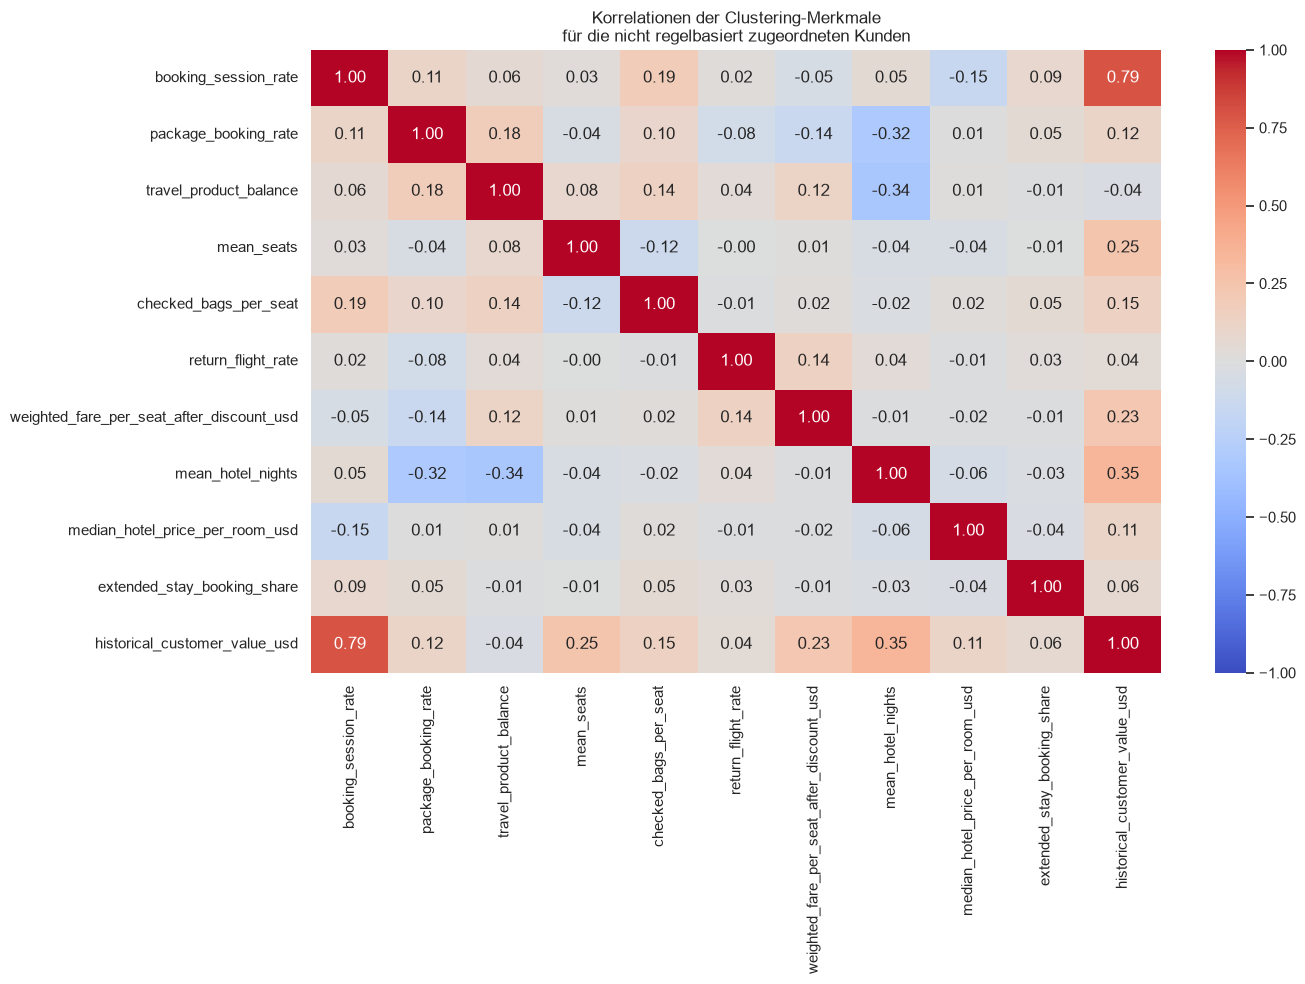

In [28]:
# Korrelation der Merkmale untersuchen

correlation_matrix_unassigned = (
    x_candidates
    .corr()
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix_unassigned,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Korrelationen der Clustering-Merkmale\n"
    "für die nicht regelbasiert zugeordneten Kunden"
)

plt.tight_layout()
plt.show()

In [29]:
# Stark korrelierte Merkmalspaare identifizieren

upper_triangle = (
    correlation_matrix_unassigned
    .where(
        np.triu(
            np.ones(
                correlation_matrix_unassigned.shape
            ),
            k=1
        ).astype(bool)
    )
)

strong_correlations_unassigned = (
    upper_triangle
    .stack()
    .reset_index()
)

strong_correlations_unassigned.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

strong_correlations_unassigned[
    "absolute_correlation"
] = (
    strong_correlations_unassigned[
        "correlation"
    ]
    .abs()
)

strong_correlations_unassigned = (
    strong_correlations_unassigned[
        strong_correlations_unassigned[
            "absolute_correlation"
        ] >= 0.70
    ]
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
)

display(strong_correlations_unassigned)

,feature_1,feature_2,correlation,absolute_correlation
10,booking_session_rate,historical_customer_value_usd,0.793,0.793


In [30]:
# Finale Merkmalsauswahl

final_clustering_features = [
    # Allgemeines Buchungsverhalten
    "booking_session_rate",
    "package_booking_rate",

    # Flug- oder Hotelorientierung
    "travel_product_balance",

    # Flugverhalten
    "mean_seats",
    "checked_bags_per_seat",
    "return_flight_rate",
    "weighted_fare_per_seat_after_discount_usd",

    # Hotelverhalten
    "mean_hotel_nights",
    "median_hotel_price_per_room_usd",
    "extended_stay_booking_share"
]

print(
    "Anzahl finaler Clustering-Merkmale:",
    len(final_clustering_features)
)

Anzahl finaler Clustering-Merkmale: 10


### Ergebnis der Merkmalsauswahl

Für die 2.817 noch nicht regelbasiert zugeordneten Kunden wurden die potenziellen Clustering-Merkmale erneut geprüft. Kein Merkmal weist in dieser Teilgruppe eine konstante Ausprägung auf.

Zwischen der Buchungsrate und dem historischen Kundenwert besteht mit rund 0,79 ein starker positiver Zusammenhang. Da die High-Value-Kunden bereits regelbasiert identifiziert wurden und die Buchungsaktivität sowie das typische Preisniveau durch andere Merkmale abgebildet werden, wird der historische Kundenwert nicht für die Berechnung der Cluster verwendet. Er bleibt jedoch für die spätere Beschreibung der entstandenen Segmente erhalten.

Die übrigen Merkmale weisen keine problematisch hohen Korrelationen auf. Die finale Auswahl umfasst zehn Variablen zum Buchungsverhalten, zur
Rabattnutzung, zur Flug- und Hotelorientierung sowie zu den jeweiligen Reisepräferenzen.

## 4. Datenvorbereitung für das Clustering

Die zehn ausgewählten Merkmale werden nun speziell für die 2.817 noch nicht regelbasiert zugeordneten Kunden vorbereitet.

Da sich die Zusammensetzung dieser Teilgruppe von der gesamten Kohorte unterscheidet, werden Imputationswerte, Transformationen und Skalierungsparameter ausschließlich auf Basis dieser Kunden berechnet. Dadurch beeinflussen die bereits regelbasiert entfernten Extremgruppen die anschließende datengetriebene Segmentierung nicht.

In [31]:
# Arbeitstabelle erstellen

cluster_user_ids = (
    unassigned_customers["user_id"]
    .copy()
)

x_cluster = (
    unassigned_customers[
        final_clustering_features
    ]
    .copy()
)

print(
    "Dimensionen der Merkmalstabelle:",
    x_cluster.shape
)

Dimensionen der Merkmalstabelle: (2817, 10)


In [32]:
# Fehlende Raten mit 0 auffüllen

zero_imputation_columns = [
    "package_booking_rate",
]

x_cluster[zero_imputation_columns] = (
    x_cluster[zero_imputation_columns]
    .fillna(0)
)

In [33]:
# Nicht definierbare Produktmerkmale mit Median imputieren

median_imputation_columns = [
    "mean_seats",
    "return_flight_rate",
    "mean_hotel_nights",
    "median_hotel_price_per_room_usd",
    "weighted_fare_per_seat_after_discount_usd"
]

imputation_values = {}


for column in median_imputation_columns:
    column_median = (
        unassigned_customers[column]
        .median()
    )

    imputation_values[column] = column_median

    x_cluster[column] = (
        x_cluster[column]
        .fillna(column_median)
    )


display(
    pd.Series(
        imputation_values,
        name="imputation_values"
    )
)

mean_seats                                    1.000
return_flight_rate                            1.000
mean_hotel_nights                             2.667
median_hotel_price_per_room_usd             147.000
weighted_fare_per_seat_after_discount_usd   334.279
Name: imputation_values, dtype: float64

In [34]:
# Imputation kontrollieren.

print(
    "Fehlende Werte insgesamt:",
    x_cluster.isna().sum().sum()
)

print(
    "Unendliche Werte insgesamt:",
    np.isinf(x_cluster).sum().sum()
)

display(
    x_cluster.describe().T
)

Fehlende Werte insgesamt: 0
Unendliche Werte insgesamt: 0


,count,mean,std,min,25%,50%,75%,max
booking_session_rate,"2,817.000",0.272,0.179,0.000,0.125,0.250,0.375,0.875
package_booking_rate,"2,817.000",0.642,0.393,0.000,0.333,0.750,1.000,1.000
travel_product_balance,"2,817.000",-0.027,0.307,-1.000,0.000,0.000,0.000,1.000
mean_seats,"2,817.000",1.119,0.284,1.000,1.000,1.000,1.000,4.000
checked_bags_per_seat,"2,817.000",0.339,0.388,0.000,0.000,0.333,0.500,3.000
return_flight_rate,"2,817.000",0.962,0.145,0.000,1.000,1.000,1.000,1.000
weighted_fare_per_seat_after_discount_usd,"2,817.000",355.874,188.747,13.680,258.756,334.279,417.860,"2,569.930"
mean_hotel_nights,"2,817.000",2.884,1.351,1.000,2.000,2.667,3.667,6.800
median_hotel_price_per_room_usd,"2,817.000",162.739,77.816,24.000,118.500,147.000,186.000,"1,005.000"
extended_stay_booking_share,"2,817.000",0.044,0.155,0.000,0.000,0.000,0.000,1.000


In [35]:
# Schiefe der Merkmale prüfen.

skewness_unassigned = (
    x_cluster
    .skew()
    .sort_values(
        key=abs,
        ascending=False
    )
    .to_frame("skewness")
)

display(skewness_unassigned)

,skewness
return_flight_rate,-4.667
extended_stay_booking_share,4.230
mean_seats,3.503
weighted_fare_per_seat_after_discount_usd,3.297
median_hotel_price_per_room_usd,2.502
checked_bags_per_seat,1.801
mean_hotel_nights,0.783
package_booking_rate,-0.644
travel_product_balance,-0.436
booking_session_rate,0.283


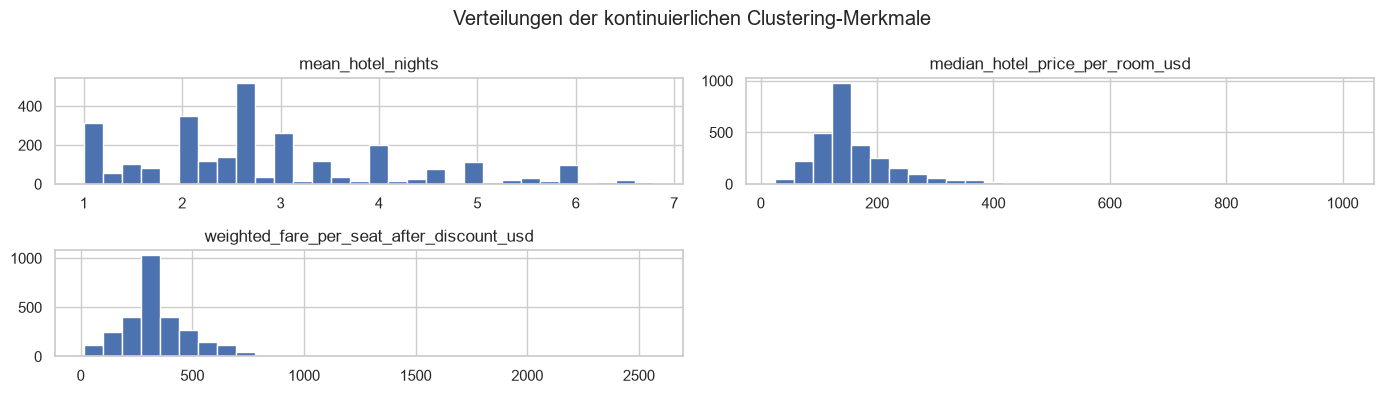

In [36]:
# Kontinuierliche Merkmale visualisieren.

continuous_features = [
    "mean_hotel_nights",
    "median_hotel_price_per_room_usd",
    "weighted_fare_per_seat_after_discount_usd"
]

x_cluster[
    continuous_features
].hist(
    bins=30,
    figsize=(14, 4)
)

plt.suptitle(
    "Verteilungen der kontinuierlichen Clustering-Merkmale"
)

plt.tight_layout()
plt.show()

In [37]:
# Stark rechtsschiefe Preismerkmale logarithmieren

x_cluster_transformed = x_cluster.copy()

log_transform_columns = [
    "median_hotel_price_per_room_usd",
    "weighted_fare_per_seat_after_discount_usd"
]

x_cluster_transformed[log_transform_columns] = (
    np.log1p(
        x_cluster_transformed[log_transform_columns]
    )
)

In [38]:
# Schiefe vor und nach der Transformation vergleichen

skewness_before_transformation = (
    x_cluster
    .skew()
    .rename("skewness_before")
)

skewness_after_transformation = (
    x_cluster_transformed
    .skew()
    .rename("skewness_after")
)

skewness_comparison_unassigned = pd.concat(
    [
        skewness_before_transformation,
        skewness_after_transformation
    ],
    axis=1
)

display(
    skewness_comparison_unassigned.loc[
        log_transform_columns
    ]
)

,skewness_before,skewness_after
median_hotel_price_per_room_usd,2.502,0.080
weighted_fare_per_seat_after_discount_usd,3.297,-0.982


In [39]:
# Skalierung der zehn Merkmale.

from sklearn.preprocessing import StandardScaler

scaler_unassigned = StandardScaler()

x_cluster_scaled_array = scaler_unassigned.fit_transform(
    x_cluster_transformed
)

x_cluster_scaled = pd.DataFrame(
    x_cluster_scaled_array,
    columns=x_cluster_transformed.columns,
    index=x_cluster_transformed.index
)

In [40]:
# Form und fehlende beziehungsweise unendliche Werte prüfen

print("Form der skalierten Daten:", x_cluster_scaled.shape)
print(
    "Fehlende Werte:",
    x_cluster_scaled.isna().sum().sum()
)
print(
    "Unendliche Werte:",
    np.isinf(x_cluster_scaled.to_numpy()).sum()
)


# Mittelwerte und Standardabweichungen kontrollieren

scaling_check_unassigned = pd.DataFrame({
    "mean": x_cluster_scaled.mean(),
    "std": x_cluster_scaled.std(ddof=0)
})

display(scaling_check_unassigned)

Form der skalierten Daten: (2817, 10)
Fehlende Werte: 0
Unendliche Werte: 0


,mean,std
booking_session_rate,-0.000,1.000
package_booking_rate,0.000,1.000
travel_product_balance,-0.000,1.000
mean_seats,-0.000,1.000
checked_bags_per_seat,-0.000,1.000
return_flight_rate,-0.000,1.000
weighted_fare_per_seat_after_discount_usd,0.000,1.000
mean_hotel_nights,-0.000,1.000
median_hotel_price_per_room_usd,-0.000,1.000
extended_stay_booking_share,-0.000,1.000


### Ergebnis der Datenvorbereitung

Für die produktbezogenen Merkmale wurden fehlende Werte abhängig von ihrer inhaltlichen Bedeutung behandelt. Fehlende Buchungsquoten wurden mit null ersetzt, wenn das betreffende Verhalten nicht beobachtet wurde. Fehlende typische Flug- und Hotelwerte wurden dagegen mit dem Median der nicht regelbasiert zugeordneten Kunden imputiert.

Die Verteilungen der Flugpreise pro Sitzplatz und der Hotelpreise pro Zimmer waren deutlich rechtsschief. Beide Merkmale wurden daher mit `log1p` transformiert. Die durchschnittliche Anzahl der Hotelnächte zeigte nur eine moderate Schiefe und wurde nicht transformiert.

Anteile, Raten und diskrete Merkmale wurden trotz teilweise hoher Schiefe in ihrer ursprünglichen Form beibehalten, da ihre Verteilungen überwiegend durch inhaltlich sinnvolle Häufungen an den Wertebereichsgrenzen geprägt sind.

Abschließend wurden alle Clustering-Merkmale standardisiert. Damit besitzen sie für die distanzbasierten Clustering-Verfahren eine vergleichbare Größenordnung. Der vorbereitete Datensatz umfasst 2.817 bislang nicht regelbasiert zugeordnete Kunden und zwölf Clustering-Merkmale.

## 5. K-Means-Clustering der nicht zugeordneten Kunden

Nach der regelbasierten Segmentierung konnten 2.817 Kunden keiner der vordefinierten Gruppen eindeutig zugeordnet werden. Für diese Kunden wird nun K-Means eingesetzt, um zusätzliche Verhaltensmuster datenbasiert zu identifizieren.

Das Clustering basiert auf den zuvor ausgewählten, imputierten, transformierten und standardisierten Merkmalen. Demografische Merkmale, der historische Kundenwert und die bereits vergebenen regelbasierten Segmente fließen nicht in die Clusterbildung ein. Sie können später zur Beschreibung und Interpretation der gefundenen Gruppen herangezogen werden.

Zunächst werden verschiedene Clusteranzahlen verglichen. Berücksichtigt werden dabei die Elbow-Methode, der Silhouette Score und die Größenverteilung der entstehenden Cluster. Die finale Clusteranzahl wird anschließend sowohl anhand der statistischen Ergebnisse als auch anhand der inhaltlichen Interpretierbarkeit ausgewählt.

In [41]:
# Verschiedene Clusteranzahlen testen

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Zu untersuchende Clusteranzahlen

k_values = range(2, 11)

kmeans_results = []


for k in k_values:
    
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    cluster_labels = kmeans_model.fit_predict(
        x_cluster_scaled
    )
    
    cluster_sizes = pd.Series(cluster_labels).value_counts()
    
    kmeans_results.append({
        "k": k,
        "inertia": kmeans_model.inertia_,
        "silhouette_score": silhouette_score(
            x_cluster_scaled,
            cluster_labels
        ),
        "smallest_cluster_size": cluster_sizes.min(),
        "smallest_cluster_share": cluster_sizes.min() / len(cluster_labels),
        "largest_cluster_size": cluster_sizes.max(),
        "largest_cluster_share": cluster_sizes.max() / len(cluster_labels)
    })


kmeans_evaluation = pd.DataFrame(kmeans_results)

display(kmeans_evaluation)

,k,inertia,silhouette_score,smallest_cluster_size,smallest_cluster_share,largest_cluster_size,largest_cluster_share
0,2,"24,129.904",0.195,651,0.231,2166,0.769
1,3,"21,954.311",0.215,182,0.065,1985,0.705
2,4,"19,939.079",0.229,168,0.060,1762,0.625
3,5,"18,317.746",0.208,158,0.056,1185,0.421
4,6,"16,876.921",0.214,139,0.049,987,0.350
5,7,"15,535.153",0.241,128,0.045,971,0.345
6,8,"14,543.242",0.237,104,0.037,711,0.252
7,9,"13,724.885",0.240,119,0.042,684,0.243
8,10,"13,008.246",0.243,92,0.033,592,0.210


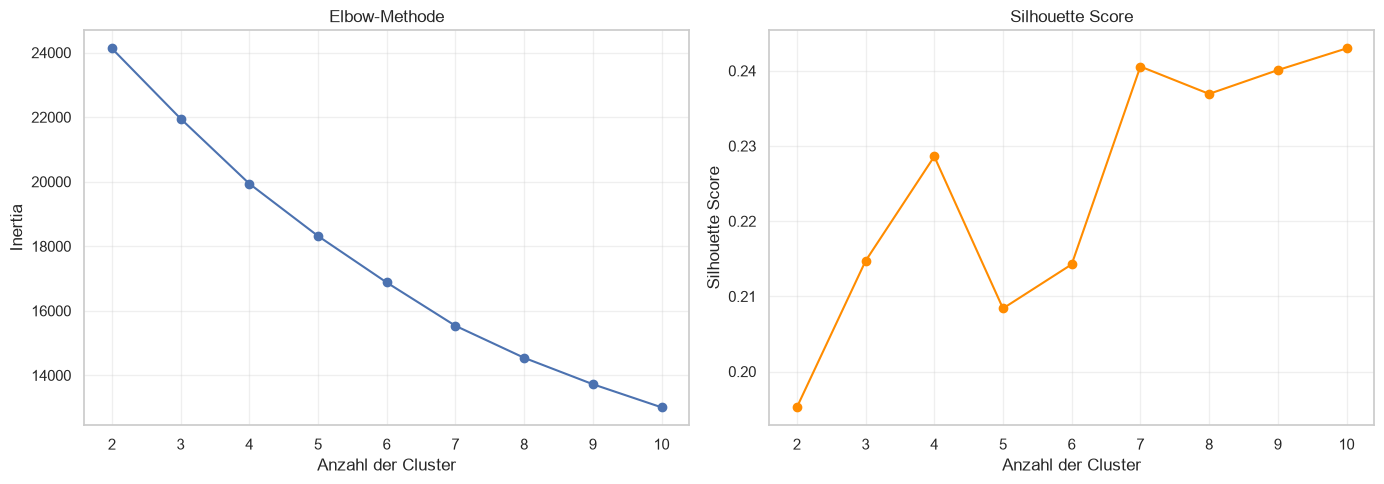

In [42]:
# Elbow-Kurve und Silhouette Score visualisieren

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    kmeans_evaluation["k"],
    kmeans_evaluation["inertia"],
    marker="o"
)

axes[0].set_title("Elbow-Methode")
axes[0].set_xlabel("Anzahl der Cluster")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(k_values))
axes[0].grid(alpha=0.3)

axes[1].plot(
    kmeans_evaluation["k"],
    kmeans_evaluation["silhouette_score"],
    marker="o",
    color="darkorange"
)

axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Anzahl der Cluster")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(k_values))
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

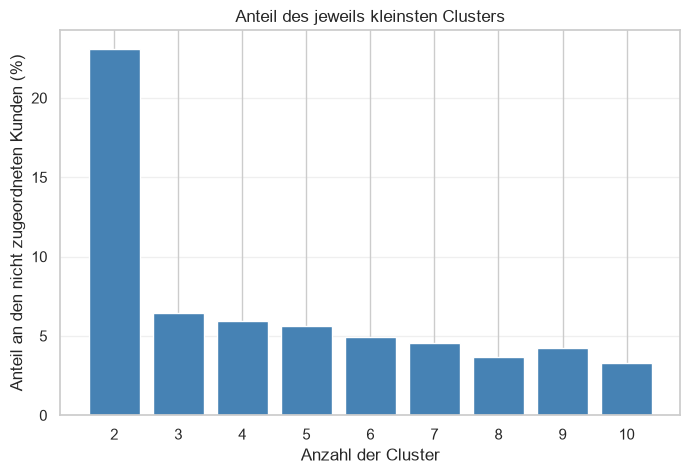

In [43]:
# Größen der jeweils kleinsten Cluster visualisieren

plt.figure(figsize=(8, 5))

plt.bar(
    kmeans_evaluation["k"].astype(str),
    kmeans_evaluation["smallest_cluster_share"] * 100,
    color="steelblue"
)

plt.title("Anteil des jeweils kleinsten Clusters")
plt.xlabel("Anzahl der Cluster")
plt.ylabel("Anteil an den nicht zugeordneten Kunden (%)")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [44]:
# Festlegung der Kandidaten für die finale Clusteranzahl.

candidate_k_values = [4, 5, 6, 7, 8, 9, 10]

In [45]:
# Vollständige Clustergrößen vergleichen.

candidate_cluster_sizes = []

candidate_labels = {}


for k in candidate_k_values:
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = model.fit_predict(x_cluster_scaled)
    
    candidate_labels[k] = labels
    
    size_table = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="customer_count")
    )
    
    size_table["customer_share"] = (
        size_table["customer_count"] / len(labels)
    )
    
    size_table.insert(0, "k", k)
    
    candidate_cluster_sizes.append(size_table)


candidate_cluster_sizes = pd.concat(
    candidate_cluster_sizes,
    ignore_index=True
)

display(candidate_cluster_sizes)

,k,cluster,customer_count,customer_share
0,4,0,249,0.088
1,4,1,1762,0.625
2,4,2,638,0.226
3,4,3,168,0.060
4,5,0,181,0.064
5,5,1,583,0.207
6,5,2,158,0.056
7,5,3,1185,0.421
8,5,4,710,0.252
9,6,0,179,0.064


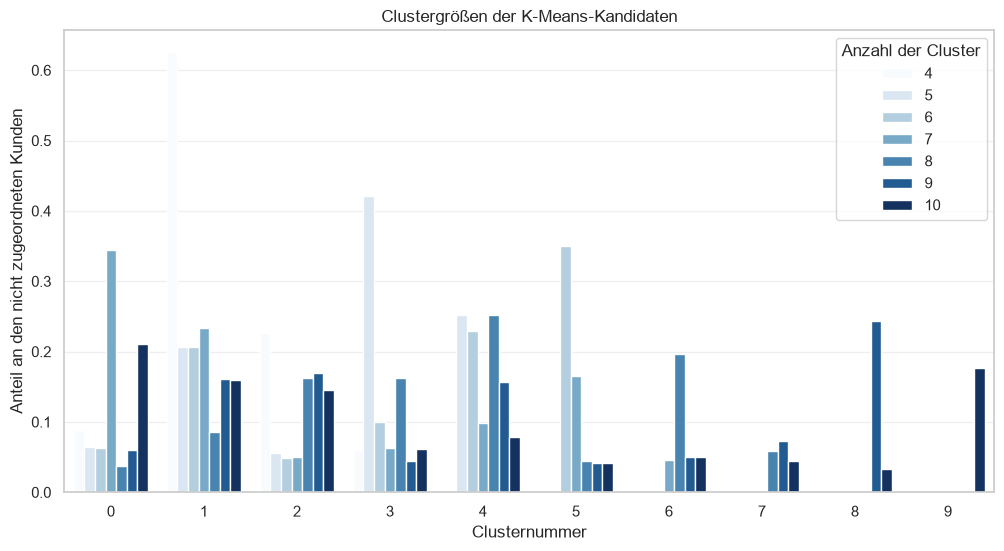

In [46]:
# Clustergrößen visualisieren

plt.figure(figsize=(12, 6))

sns.barplot(
    data=candidate_cluster_sizes,
    x="cluster",
    y="customer_share",
    hue="k",
    palette="Blues"
)

plt.title("Clustergrößen der K-Means-Kandidaten")
plt.xlabel("Clusternummer")
plt.ylabel("Anteil an den nicht zugeordneten Kunden")
plt.legend(title="Anzahl der Cluster")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [47]:
# Stabilität der Kandidaten untersuchen.

from sklearn.metrics import adjusted_rand_score


random_states = [
    0, 1, 2, 3, 4,
    10, 20, 30, 40, 42
]

stability_results = []


for k in candidate_k_values:
    
    reference_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    reference_labels = reference_model.fit_predict(
        x_cluster_scaled
    )
    
    ari_scores = []
    
    for random_state in random_states:
        
        comparison_model = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=20
        )
        
        comparison_labels = comparison_model.fit_predict(
            x_cluster_scaled
        )
        
        ari_scores.append(
            adjusted_rand_score(
                reference_labels,
                comparison_labels
            )
        )
    
    stability_results.append({
        "k": k,
        "mean_ari": np.mean(ari_scores),
        "minimum_ari": np.min(ari_scores),
        "maximum_ari": np.max(ari_scores),
        "std_ari": np.std(ari_scores)
    })


kmeans_stability = pd.DataFrame(stability_results)

display(kmeans_stability)

,k,mean_ari,minimum_ari,maximum_ari,std_ari
0,4,0.776,0.471,1.000,0.243
1,5,0.839,0.483,1.000,0.215
2,6,0.966,0.941,1.000,0.023
3,7,0.945,0.919,1.000,0.029
4,8,0.834,0.718,1.000,0.096
5,9,0.889,0.841,1.000,0.041
6,10,0.929,0.895,1.000,0.029


In [48]:
# Standardisierte Clusterprofile vorbereiten.

candidate_cluster_profiles = {}


for k in candidate_k_values:
    
    profile_data = x_cluster_scaled.copy()
    profile_data["cluster"] = candidate_labels[k]
    
    candidate_cluster_profiles[k] = (
        profile_data
        .groupby("cluster")
        .mean()
    )

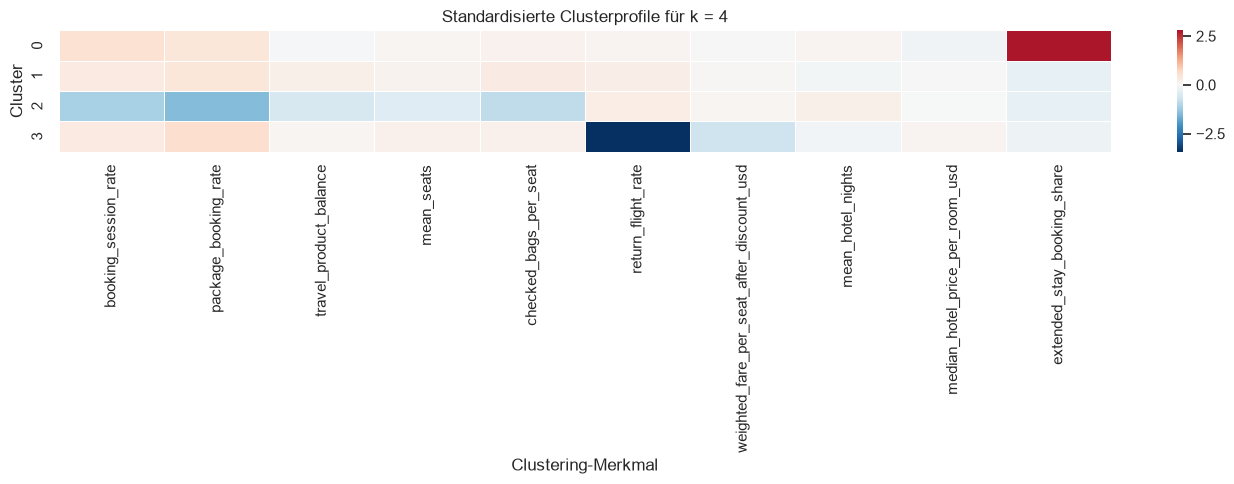

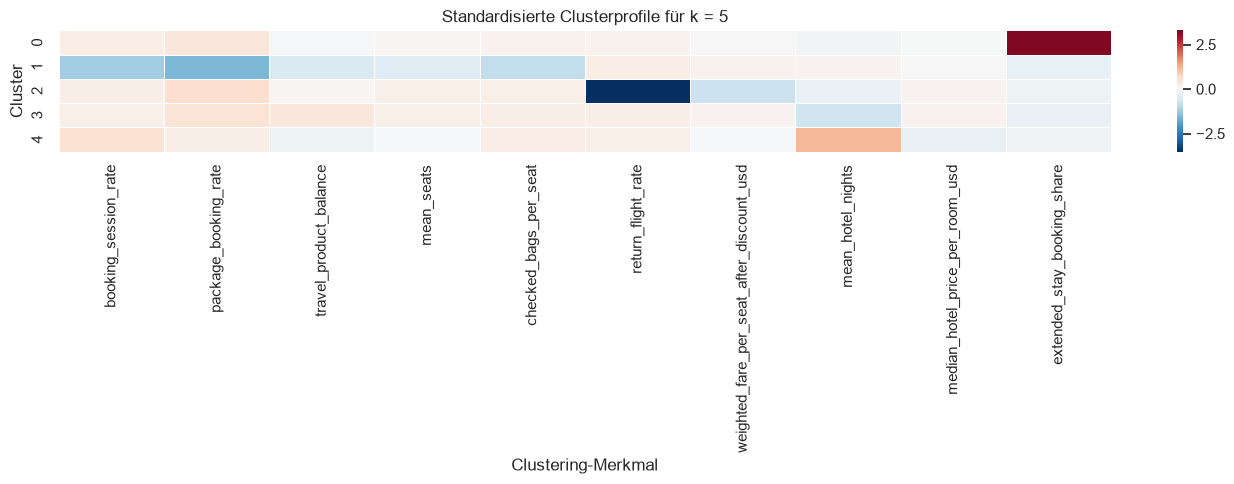

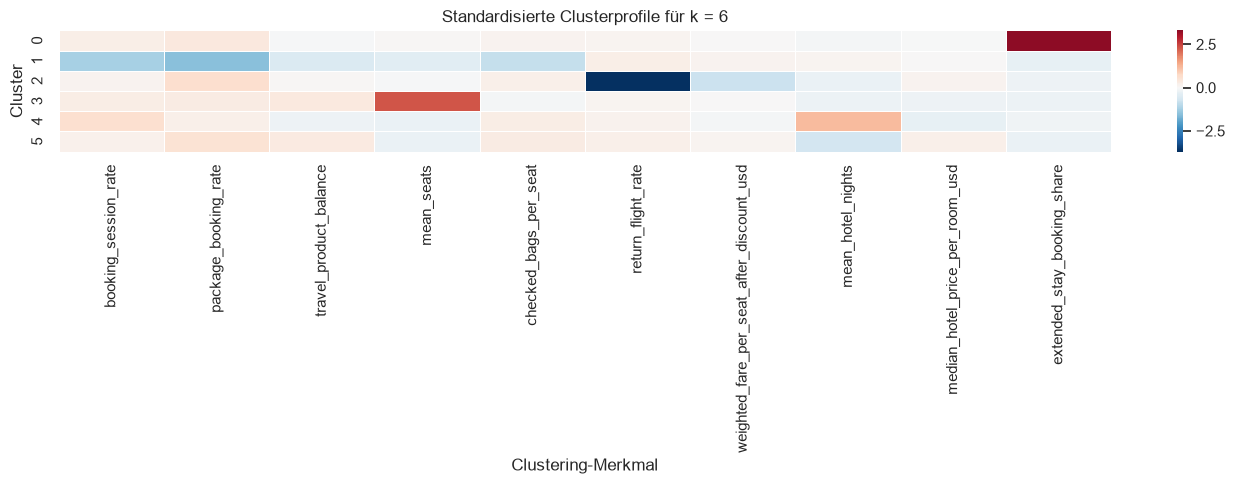

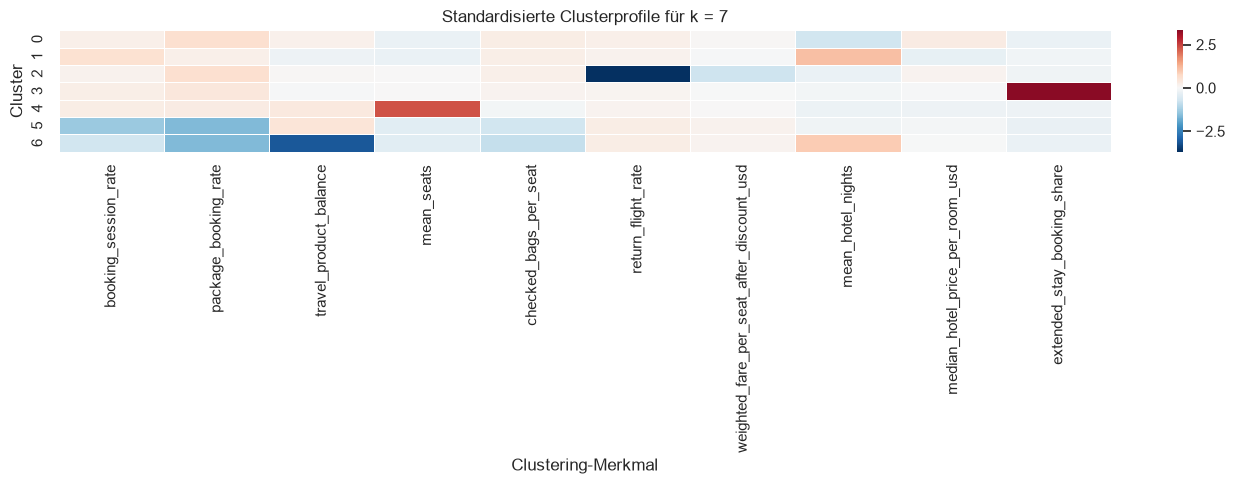

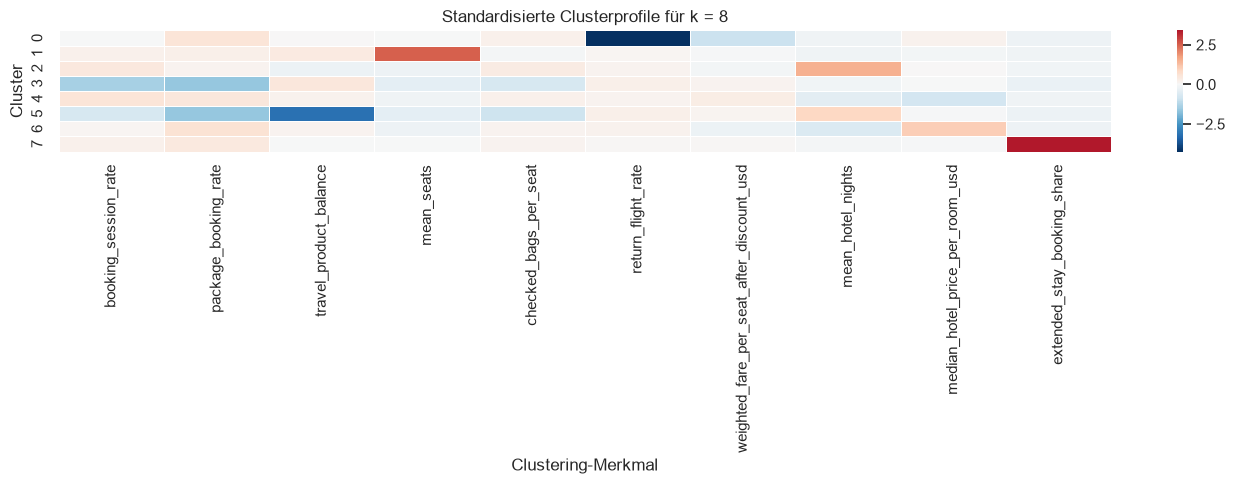

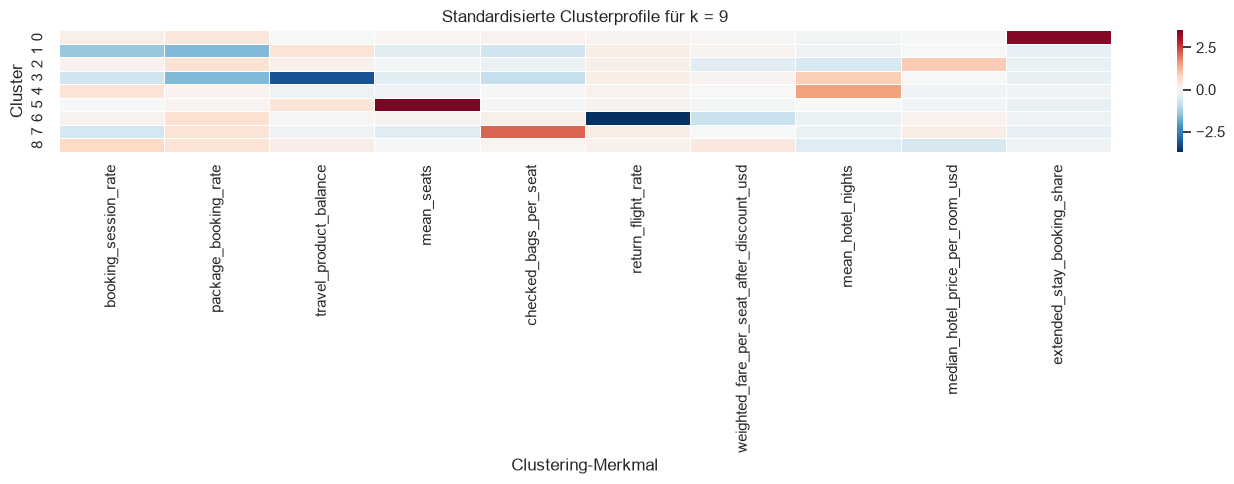

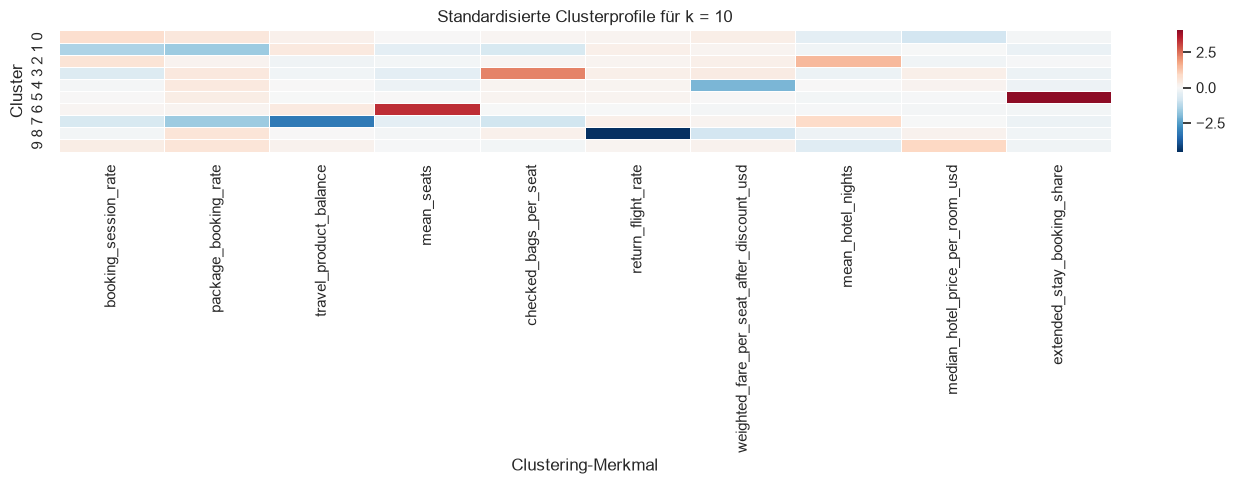

In [49]:
# Standardisierte Clusterprofile visualisieren.

for k in candidate_k_values:
    
    plt.figure(figsize=(14, 5))
    
    sns.heatmap(
        candidate_cluster_profiles[k],
        cmap="RdBu_r",
        center=0,
        annot=False,
        linewidths=0.5
    )
    
    plt.title(
        f"Standardisierte Clusterprofile für k = {k}"
    )
    
    plt.xlabel("Clustering-Merkmal")
    plt.ylabel("Cluster")
    
    plt.tight_layout()
    plt.show()

### Auswahl der Clusteranzahl

Zur Auswahl einer geeigneten Clusteranzahl wurden Lösungen mit vier bis zehn Clustern hinsichtlich Silhouette Score, Clustergrößen, Stabilität und inhaltlicher Interpretierbarkeit verglichen.

Der Silhouette Score stieg mit zunehmender Clusteranzahl an und erreichte bei zehn Clustern den höchsten Wert. Die Verbesserung gegenüber kompakteren Lösungen war jedoch vergleichsweise gering. Gleichzeitig hätten sieben bis zehn zusätzliche Cluster zusammen mit den sechs regelbasierten Segmenten zu einer sehr kleinteiligen und operativ schwer handhabbaren Kundensegmentierung geführt.

Die Lösung mit sechs Clustern erreicht mit einem durchschnittlichen Adjusted Rand Index von 0,966 und einem niedrigsten Wert von 0,941 eine sehr hohe Stabilität über verschiedene Initialisierungen hinweg. Außerdem entstehen sechs grundsätzlich unterscheidbare Verhaltensmuster hinsichtlich Buchungsbereitschaft, Reisegruppengröße, Flugverhalten sowie Art, Dauer und Preisniveau der Hotelaufenthalte, ohne bereits regelbasiert abgebildete Kundengruppen unnötig weiter zu unterteilen.

Aus diesem Grund wird für die bislang nicht zugeordneten Kunden eine K-Means-Lösung mit sechs Clustern gewählt. Damit umfasst die kombinierte Segmentierung insgesamt sechs regelbasierte und sechs datenbasierte Kundengruppen.

In [50]:
# Finales K-Means-Modell berechnen

final_k = 6

final_kmeans_model = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

final_kmeans_labels = final_kmeans_model.fit_predict(
    x_cluster_scaled
)

In [51]:
# Clusterzuordnung ergänzen

unassigned_clustered = unassigned_customers.loc[
    x_cluster.index
].copy()

unassigned_clustered["kmeans_cluster"] = (
    final_kmeans_labels
)

print(
    "Kunden in der Clustertabelle:",
    len(unassigned_clustered)
)

print(
    "Fehlende Clusterzuordnungen:",
    unassigned_clustered["kmeans_cluster"].isna().sum()
)

display(
    unassigned_clustered["kmeans_cluster"]
    .value_counts()
    .sort_index()
)

Kunden in der Clustertabelle: 2817
Fehlende Clusterzuordnungen: 0


kmeans_cluster
0    179
1    583
2    139
3    282
4    647
5    987
Name: count, dtype: int64

In [52]:
# Clusterprofile in den ursprünglichen Einheiten anzeigen.

cluster_profile_data = x_cluster.copy()

cluster_profile_data["kmeans_cluster"] = (
    final_kmeans_labels
)


cluster_profiles_original = (
    cluster_profile_data
    .groupby("kmeans_cluster")
    .mean()
    .round(3)
)

display(cluster_profiles_original)

,booking_session_rate,package_booking_rate,travel_product_balance,mean_seats,checked_bags_per_seat,return_flight_rate,weighted_fare_per_seat_after_discount_usd,mean_hotel_nights,median_hotel_price_per_room_usd,extended_stay_booking_share
kmeans_cluster,,,,,,,,,,
0,0.317,0.800,-0.038,1.125,0.384,0.975,357.479,2.765,162.573,0.555
1,0.054,0.030,-0.191,1.000,0.000,1.000,344.679,2.990,155.811,0.000
2,0.299,0.879,-0.017,1.106,0.424,0.425,244.808,2.542,171.313,0.018
3,0.321,0.764,0.081,1.782,0.313,0.976,384.342,2.590,148.679,0.014
4,0.374,0.733,-0.081,1.047,0.450,0.985,348.963,4.432,143.403,0.021
5,0.307,0.848,0.076,1.047,0.454,0.994,374.234,1.962,182.347,0.006


In [53]:
# Mediane der Cluster berechnen.

cluster_profiles_median = (
    cluster_profile_data
    .groupby("kmeans_cluster")
    .median()
    .round(3)
)

display(cluster_profiles_median)

,booking_session_rate,package_booking_rate,travel_product_balance,mean_seats,checked_bags_per_seat,return_flight_rate,weighted_fare_per_seat_after_discount_usd,mean_hotel_nights,median_hotel_price_per_room_usd,extended_stay_booking_share
kmeans_cluster,,,,,,,,,,
0,0.333,1.000,0.000,1.000,0.333,1.000,334.279,2.667,150.000,0.500
1,0.000,0.000,0.000,1.000,0.000,1.000,334.279,2.667,147.000,0.000
2,0.250,1.000,0.000,1.000,0.500,0.500,225.955,2.333,154.000,0.000
3,0.250,1.000,0.000,1.667,0.333,1.000,312.580,2.500,141.250,0.000
4,0.375,0.750,0.000,1.000,0.500,1.000,334.027,4.250,132.000,0.000
5,0.250,1.000,0.000,1.000,0.500,1.000,354.308,2.000,159.000,0.000


In [54]:
# Kompakte Größenübersicht der Cluster erstellen.

final_cluster_sizes = (
    unassigned_clustered
    .groupby("kmeans_cluster")
    .size()
    .rename("customer_count")
    .to_frame()
)

final_cluster_sizes["customer_share"] = (
    final_cluster_sizes["customer_count"]
    / final_cluster_sizes["customer_count"].sum()
)

display(final_cluster_sizes)

,customer_count,customer_share
kmeans_cluster,,
0,179,0.064
1,583,0.207
2,139,0.049
3,282,0.100
4,647,0.230
5,987,0.350


In [55]:
# Ergänzung von Segmentbezeichnungen für die K-Means-Cluster.

kmeans_segment_mapping = {
    0: "Extended-Stay Hotel Guests",
    1: "Low-Conversion Browsers",
    2: "Flexible One-Way Flyers",
    3: "Multi-Person Travelers",
    4: "Active Longer-Stay Hotel Guests",
    5: "Premium Short-Stay Package Travelers"
}

unassigned_clustered["segment"] = (
    unassigned_clustered["kmeans_cluster"]
    .map(kmeans_segment_mapping)
)

display(
    unassigned_clustered[
        ["user_id", "kmeans_cluster", "segment"]
    ].head()
)

,user_id,kmeans_cluster,segment
0,94883,3,Multi-Person Travelers
1,101486,4,Active Longer-Stay Hotel Guests
2,101961,4,Active Longer-Stay Hotel Guests
3,133058,1,Low-Conversion Browsers
4,152583,5,Premium Short-Stay Package Travelers


### Interpretation der K-Means-Cluster

Die Lösung mit sechs Clustern unterteilt die bislang nicht regelbasiert zugeordneten Kunden in sechs unterscheidbare Verhaltensgruppen.

Die **Low-Conversion Browsers** zeigen trotz vorhandener Sessions bislang nur eine sehr geringe Buchungsaktivität. Ihre Buchungs- und Paketreiseraten liegen deutlich unter denen der übrigen Cluster. Da für viele dieser Kunden keine Flug- oder Hotelbuchungen vorliegen, beruhen einzelne produktspezifische Werte auf der Median-Imputation und werden bei der inhaltlichen Beschreibung der Gruppe nicht berücksichtigt.

Die **Extended-Stay Hotel Guests** weisen einen besonders hohen Anteil an Buchungen bei Extended-Stay-Unterkünften (= Apartment-ähnlichen Unterkünften) auf. Dies beschreibt die bevorzugte Unterkunftsart, bedeutet jedoch nicht automatisch längere Aufenthalte: Die durchschnittliche Aufenthaltsdauer dieser Gruppe liegt bei knapp drei Nächten.

Die **Multi-Person Travelers** buchen mit durchschnittlich 1,78 Sitzplätzen deutlich häufiger für mehrere Personen als die übrigen datenbasierten Cluster. Die Bezeichnung bezieht sich bewusst auf die Anzahl der Reisenden und lässt keinen direkten Rückschluss darauf zu, ob es sich um Familien, Paare oder andere Reisegruppen handelt.

Die **Flexible One-Way Flyers** besitzen mit rund 43 % eine auffällig niedrige Rückflugquote. Gleichzeitig weisen sie vergleichsweise niedrige Flugpreise je Sitzplatz auf. Da in diesem Cluster keine stornierten Flüge vorliegen, lässt sich die geringe Rückflugquote nicht durch Stornierungen erklären. Sie deutet vielmehr auf ein flexibleres, häufiger durch Einzelstrecken geprägtes Flugverhalten hin.

Die **Active Longer-Stay Hotel Guests** besitzen die höchste Buchungsrate der sechs Cluster und verbringen mit durchschnittlich rund 4,5 Nächten vergleichsweise lange Zeit im Hotel. Die Bezeichnung „Longer-Stay“ beschreibt dabei den relativen Unterschied zu den übrigen Clustern und ist von der regelbasierten Long-Stay-Grenze von mindestens sieben Nächten abzugrenzen.

Die **Premium Short-Stay Package Travelers** bilden die größte datenbasierte Gruppe. Sie buchen besonders häufig kombinierte Flug- und Hotelreisen, übernachten vergleichsweise kurz und wählen dabei das höchste durchschnittliche Hotelpreisniveau der sechs Cluster.

Die datenbasierten Cluster ergänzen damit die zuvor regelbasiert definierten Segmente. Während die regelbasierten Gruppen besonders klar ausgeprägte Merkmale und Bedürfnisse abbilden, differenziert K-Means die verbleibenden Kunden anhand ihrer Buchungsbereitschaft, Reisegruppengröße, Flugstruktur sowie Art, Dauer und Preisniveau ihrer Hotelaufenthalte. Rabattmerkmale wurden nicht zur Bildung der finalen Cluster verwendet, können jedoch weiterhin zur Profilierung und zur anschließenden Perk-Zuweisung herangezogen werden.

### Ergänzende Profilierung der K-Means-Cluster

Zur inhaltlichen Beschreibung der K-Means-Cluster werden ergänzende Merkmale herangezogen, die nicht in die Clusterbildung eingeflossen sind. Dazu gehören insbesondere demografische Eigenschaften, absolute Buchungszahlen und der historische Kundenwert.

Diese Merkmale verändern die Clusterzuordnung nicht. Sie dienen ausschließlich dazu, die gefundenen Gruppen besser zu verstehen und später geeignete Marketingmaßnahmen und Rewards-Benefits abzuleiten.

Die bisherigen Segmentbezeichnungen werden zunächst als Arbeitsnamen verwendet. Die endgültige Benennung erfolgt nach dem Vergleich mit DBSCAN und der Visualisierung mittels PCA.

In [56]:
# Verfügbare Profilmerkmale bestimmen.

profiling_candidates = [
    # Demografie
    "age",
    "has_children",
    "married",

    # Kundenaktivität
    "session_count",
    "booking_session_count",
    "flight_booking_count",
    "hotel_booking_count",

    # Absolute Reiseaktivität
    "total_seats",
    "total_checked_bags",
    "total_hotel_nights",
    "total_rooms",

    # Ausgaben und Kundenwert
    "total_flight_spend_before_discount_usd",
    "total_flight_spend_after_discount_usd",
    "total_hotel_spend_usd",
    "historical_customer_value_usd"
]

available_profiling_columns = [
    column
    for column in profiling_candidates
    if column in unassigned_clustered.columns
]

missing_profiling_columns = [
    column
    for column in profiling_candidates
    if column not in unassigned_clustered.columns
]

print("Verfügbare Profilmerkmale:")
print(available_profiling_columns)

print("\nNicht vorhandene Kandidaten:")
print(missing_profiling_columns)

Verfügbare Profilmerkmale:
['age', 'has_children', 'married', 'session_count', 'booking_session_count', 'flight_booking_count', 'hotel_booking_count', 'total_seats', 'total_checked_bags', 'total_hotel_nights', 'total_rooms', 'historical_customer_value_usd']

Nicht vorhandene Kandidaten:
['total_flight_spend_before_discount_usd', 'total_flight_spend_after_discount_usd', 'total_hotel_spend_usd']


In [57]:
# Mittelwerte nach Clustern berechnen.

cluster_profile_means_extended = (
    unassigned_clustered
    .groupby(
        ["kmeans_cluster", "segment"]
    )[available_profiling_columns]
    .mean()
    .round(2)
)

display(cluster_profile_means_extended)

,,age,has_children,married,session_count,booking_session_count,flight_booking_count,hotel_booking_count,total_seats,total_checked_bags,total_hotel_nights,total_rooms,historical_customer_value_usd
kmeans_cluster,segment,,,,,,,,,,,,
0,Extended-Stay Hotel Guests,42.370,0.320,0.470,8.160,2.580,2.290,2.350,2.620,0.980,6.690,2.670,"2,174.970"
1,Low-Conversion Browsers,41.550,0.370,0.490,8.190,0.450,0.120,0.390,0.120,0.000,1.420,0.500,382.500
2,Flexible One-Way Flyers,41.060,0.370,0.410,8.290,2.470,2.240,2.360,2.490,0.990,6.220,2.650,"1,795.900"
3,Multi-Person Travelers,41.370,0.190,0.420,8.230,2.630,2.410,2.240,4.120,1.280,5.720,3.720,"2,821.720"
4,Active Longer-Stay Hotel Guests,41.450,0.300,0.440,8.190,3.050,2.470,2.790,2.610,1.070,12.090,3.040,"2,832.560"
5,Premium Short-Stay Package Travelers,42.020,0.350,0.470,8.190,2.520,2.430,2.200,2.600,1.060,4.400,2.360,"1,835.460"


In [58]:
# Mediane nach Cluster berechnen.

cluster_profile_medians_extended = (
    unassigned_clustered
    .groupby(
        ["kmeans_cluster", "segment"]
    )[available_profiling_columns]
    .median()
    .round(2)
)

display(cluster_profile_medians_extended)

,,age,has_children,married,session_count,booking_session_count,flight_booking_count,hotel_booking_count,total_seats,total_checked_bags,total_hotel_nights,total_rooms,historical_customer_value_usd
kmeans_cluster,segment,,,,,,,,,,,,
0,Extended-Stay Hotel Guests,42.000,0.000,0.000,8.000,3.000,2.000,2.000,3.000,1.000,6.000,3.000,"1,881.290"
1,Low-Conversion Browsers,37.000,0.000,0.000,8.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,Flexible One-Way Flyers,41.000,0.000,0.000,8.000,2.000,2.000,2.000,2.000,1.000,5.000,3.000,"1,628.770"
3,Multi-Person Travelers,41.000,0.000,0.000,8.000,2.000,2.000,2.000,4.000,1.000,5.000,4.000,"2,677.270"
4,Active Longer-Stay Hotel Guests,41.000,0.000,0.000,8.000,3.000,2.000,3.000,3.000,1.000,12.000,3.000,"2,713.570"
5,Premium Short-Stay Package Travelers,42.000,0.000,0.000,8.000,2.000,2.000,2.000,2.000,1.000,4.000,2.000,"1,619.530"


In [59]:
# Demografische Anteile gesondert darstellen.

demographic_share_columns = [
    column
    for column in [
        "has_children",
        "married"
    ]
    if column in unassigned_clustered.columns
]

if demographic_share_columns:
    
    cluster_demographic_shares = (
        unassigned_clustered
        .groupby(
            ["kmeans_cluster", "segment"]
        )[demographic_share_columns]
        .mean()
        .mul(100)
        .round(1)
    )
    
    cluster_demographic_shares.columns = [
        f"{column}_share_percent"
        for column in cluster_demographic_shares.columns
    ]
    
    display(cluster_demographic_shares)

,,has_children_share_percent,married_share_percent
kmeans_cluster,segment,,
0,Extended-Stay Hotel Guests,31.800,47.500
1,Low-Conversion Browsers,36.900,48.700
2,Flexible One-Way Flyers,36.700,41.000
3,Multi-Person Travelers,19.100,42.200
4,Active Longer-Stay Hotel Guests,30.100,44.000
5,Premium Short-Stay Package Travelers,35.400,46.800


In [60]:
# Geschlechterverteilung prüfen.

if "gender" in unassigned_clustered.columns:
    
    cluster_gender_distribution = (
        pd.crosstab(
            unassigned_clustered["segment"],
            unassigned_clustered["gender"],
            normalize="index"
        )
        .mul(100)
        .round(1)
    )
    
    display(cluster_gender_distribution)

gender,F,M,O
segment,,,
Active Longer-Stay Hotel Guests,87.000,12.800,0.200
Extended-Stay Hotel Guests,91.100,8.900,0.000
Flexible One-Way Flyers,87.800,12.200,0.000
Low-Conversion Browsers,87.100,12.700,0.200
Multi-Person Travelers,87.200,12.400,0.400
Premium Short-Stay Package Travelers,88.600,11.100,0.300


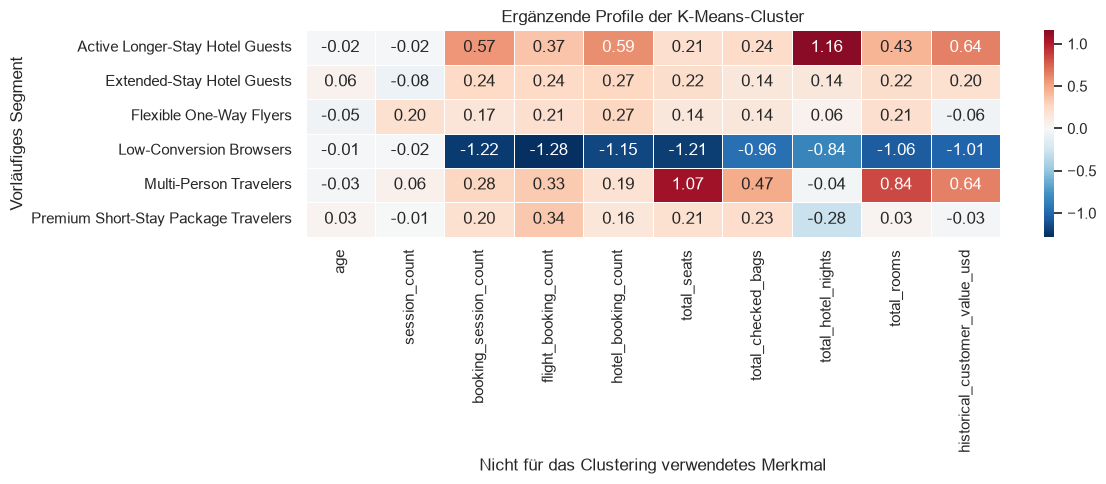

In [61]:
# Abweichungen vom Durchschnitt visualisieren.

numeric_profile_columns = [
    column
    for column in available_profiling_columns
    if pd.api.types.is_numeric_dtype(
        unassigned_clustered[column]
    )
    and column not in ["has_children", "married"]
]


cluster_profile_for_heatmap = (
    unassigned_clustered
    .groupby("segment")[numeric_profile_columns]
    .mean()
)


overall_means = (
    unassigned_clustered[numeric_profile_columns]
    .mean()
)

overall_std = (
    unassigned_clustered[numeric_profile_columns]
    .std()
    .replace(0, np.nan)
)


cluster_profile_deviation = (
    cluster_profile_for_heatmap - overall_means
) / overall_std


plt.figure(
    figsize=(
        max(12, len(numeric_profile_columns) * 1.1),
        5
    )
)

sns.heatmap(
    cluster_profile_deviation,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Ergänzende Profile der K-Means-Cluster"
)
plt.xlabel("Nicht für das Clustering verwendetes Merkmal")
plt.ylabel("Vorläufiges Segment")

plt.tight_layout()
plt.show()

### Ergebnisse des ergänzenden Cluster-Profilings

Die ergänzende Profilierung bestätigt die anhand der Clustering-Merkmale abgeleiteten Arbeitsnamen.

Die **Low-Conversion Browsers** weisen mit durchschnittlich nur 0,45 Buchungssessions, kaum Flug- oder Hotelbuchungen und einem historischen
Kundenwert von rund 383 US-Dollar die geringste bisherige Kundenaktivität auf. Der Median der Buchungs- und Umsatzmerkmale liegt in dieser Gruppe überwiegend bei null. Das ergänzende Profiling bestätigt damit die zuvor identifizierte niedrige Buchungsbereitschaft.

Die **Extended-Stay Hotel Guests** zeigen eine insgesamt durchschnittliche Buchungsaktivität. Sie kommen auf rund 2,6 Buchungssessions sowie jeweils etwas mehr als zwei Flug- und Hotelbuchungen. Ihr historischer Kundenwert liegt bei rund 2.175 US-Dollar. Ihr charakteristisches Merkmal bleibt damit nicht ein außergewöhnlich hohes allgemeines Buchungsvolumen, sondern die überproportionale Nutzung von Extended-Stay-Unterkünften.

Die **Flexible One-Way Flyers** besitzen ebenfalls eine regelmäßige Flug- und Hotelaktivität. Ihr historischer Kundenwert liegt bei rund 1.796 US-Dollar. Ihre Abgrenzung gegenüber den übrigen Gruppen erfolgt vor allem über die niedrige Rückflugquote und nicht über demografische Merkmale oder ein besonders hohes Buchungsvolumen.

Die **Multi-Person Travelers** buchen durchschnittlich mehr als vier Sitzplätze und damit deutlich mehr als alle anderen datenbasierten Gruppen. Gleichzeitig weisen sie einen vergleichsweise hohen historischen Kundenwert von rund 2.822 US-Dollar auf. Der niedrige Anteil von Kunden mit Kindern zeigt jedoch, dass Mehrpersonenbuchungen nicht automatisch als Familienreisen interpretiert werden dürfen. Denkbar sind ebenso Reisen mit Partnern, Freunden oder anderen Gruppen.

Die **Active Longer-Stay Hotel Guests** weisen mit durchschnittlich rund drei Buchungssessions, 2,8 Hotelbuchungen und insgesamt etwa zwölf gebuchten Hotelnächten die höchste Hotelaktivität auf. Mit rund 2.833 US-Dollar besitzen sie zugleich den höchsten durchschnittlichen historischen Kundenwert der sechs K-Means-Cluster. Das ergänzende Profil bestätigt damit sowohl ihre hohe Buchungsaktivität als auch ihre überdurchschnittlich langen Hotelaufenthalte.

Die **Premium Short-Stay Package Travelers** buchen regelmäßig Flug- und Hotelangebote, verbringen jedoch insgesamt weniger Nächte im Hotel. Ihr historischer Kundenwert liegt bei rund 1.835 US-Dollar. Ihre Besonderheit liegt somit weniger im gesamten Buchungsvolumen als in der Kombination aus hoher Paketreiserate, kurzen Aufenthalten und einem vergleichsweise hohen Hotelpreisniveau.

Die demografischen Merkmale unterscheiden sich zwischen den Clustern nur geringfügig. Das Durchschnittsalter liegt in allen Gruppen bei etwa 41 bis 42 Jahren. Auch der Familienstand und der Anteil der Kunden mit Kindern zeigen überwiegend moderate Unterschiede. Die Cluster werden somit hauptsächlich durch das tatsächliche Reise- und Buchungsverhalten und nicht durch das Alter oder den Familienstand geprägt.

Die Segmentnamen werden bis zum Vergleich mit DBSCAN und zur PCA-Visualisierung weiterhin als Arbeitsnamen behandelt.

## 6. DBSCAN als Vergleichsverfahren

DBSCAN wird als alternatives Clustering-Verfahren eingesetzt, um zu prüfen,
ob sich in den nicht regelbasiert zugeordneten Kunden natürliche
Dichtebereiche erkennen lassen.

Im Gegensatz zu K-Means muss bei DBSCAN die Anzahl der Cluster nicht vorab
festgelegt werden. Das Verfahren gruppiert eng beieinanderliegende Kunden
und kennzeichnet Kunden außerhalb ausreichend dichter Bereiche als
Rauschpunkte beziehungsweise Ausreißer.

Die beiden zentralen Parameter sind:

- `eps`: maximaler Abstand zwischen benachbarten Datenpunkten,
- `min_samples`: Mindestanzahl an Datenpunkten innerhalb eines dichten
  Bereichs.

DBSCAN wird auf denselben transformierten und standardisierten Merkmalen wie
K-Means durchgeführt. Das Ergebnis dient zunächst als methodischer Vergleich
und ersetzt nicht automatisch die zuvor ausgewählte K-Means-Lösung.

In [62]:
# Ausgangswert für min_samples
 
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score


number_of_features = x_cluster_scaled.shape[1]

min_samples_initial = 2 * number_of_features

print("Anzahl der Merkmale:", number_of_features)
print("Ausgangswert für min_samples:", min_samples_initial)

Anzahl der Merkmale: 10
Ausgangswert für min_samples: 20


In [63]:
# K-Distanz berechnen.

nearest_neighbors = NearestNeighbors(
    n_neighbors=min_samples_initial
)

nearest_neighbors.fit(x_cluster_scaled)

neighbor_distances, neighbor_indices = (
    nearest_neighbors.kneighbors(x_cluster_scaled)
)


k_distances = np.sort(
    neighbor_distances[:, -1]
)

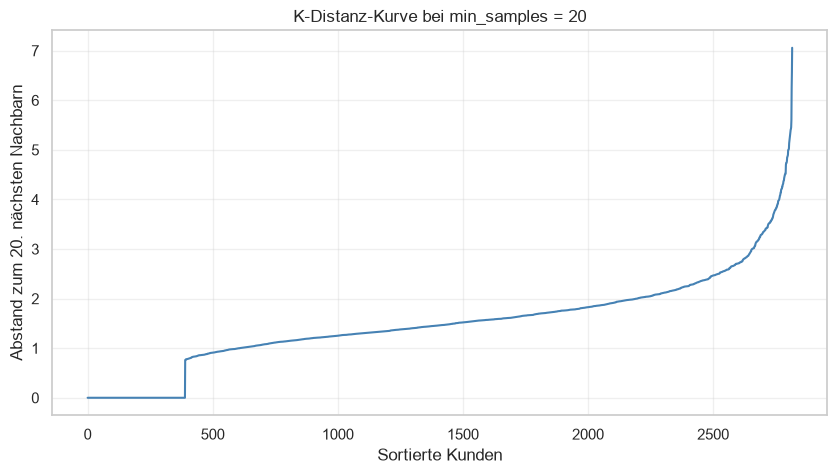

In [64]:
# K-Distanz-Kurve darstellen.

plt.figure(figsize=(10, 5))

plt.plot(
    k_distances,
    color="steelblue"
)

plt.title(
    f"K-Distanz-Kurve bei min_samples = {min_samples_initial}"
)
plt.xlabel("Sortierte Kunden")
plt.ylabel(
    f"Abstand zum {min_samples_initial}. nächsten Nachbarn"
)

plt.grid(alpha=0.3)
plt.show()

In [66]:
# Quantile der K-Distanzen prüfen.

distance_quantiles = (
    pd.Series(k_distances)
    .quantile([
        0.80,
        0.85,
        0.90,
        0.92,
        0.94,
        0.95,
        0.96,
        0.97,
        0.98,
        0.99
    ])
    .rename("eps_candidate")
    .to_frame()
)

display(distance_quantiles)

,eps_candidate
0.800,2.054
0.850,2.248
0.900,2.536
0.920,2.697
0.940,2.918
0.950,3.152
0.960,3.354
0.970,3.574
0.980,3.948
0.990,4.504


In [67]:
# Erste DBSCAN-Parameter testen

eps_candidates = np.unique(
    np.round(
        distance_quantiles["eps_candidate"].to_numpy(),
        3
    )
)

dbscan_results = []


for eps in eps_candidates:
    
    dbscan_model = DBSCAN(
        eps=eps,
        min_samples=min_samples_initial
    )
    
    dbscan_labels = dbscan_model.fit_predict(
        x_cluster_scaled
    )
    
    non_noise_mask = dbscan_labels != -1
    
    cluster_labels_without_noise = (
        dbscan_labels[non_noise_mask]
    )
    
    unique_clusters = set(dbscan_labels)
    unique_clusters.discard(-1)
    
    number_of_clusters = len(unique_clusters)
    number_of_noise_points = (~non_noise_mask).sum()
    noise_share = (
        number_of_noise_points / len(dbscan_labels)
    )
    
    if number_of_clusters >= 2:
        
        silhouette = silhouette_score(
            x_cluster_scaled.iloc[non_noise_mask],
            cluster_labels_without_noise
        )
        
        cluster_sizes = (
            pd.Series(cluster_labels_without_noise)
            .value_counts()
        )
        
        smallest_cluster_size = cluster_sizes.min()
        largest_cluster_size = cluster_sizes.max()
    
    else:
        silhouette = np.nan
        smallest_cluster_size = np.nan
        largest_cluster_size = np.nan
    
    dbscan_results.append({
        "eps": eps,
        "min_samples": min_samples_initial,
        "number_of_clusters": number_of_clusters,
        "noise_count": number_of_noise_points,
        "noise_share": noise_share,
        "silhouette_without_noise": silhouette,
        "smallest_cluster_size": smallest_cluster_size,
        "largest_cluster_size": largest_cluster_size
    })


dbscan_evaluation = pd.DataFrame(dbscan_results)

display(dbscan_evaluation)

,eps,min_samples,number_of_clusters,noise_count,noise_share,silhouette_without_noise,smallest_cluster_size,largest_cluster_size
0,2.054,20,1,224,0.080,NaN,NaN,NaN
1,2.248,20,1,181,0.064,NaN,NaN,NaN
2,2.536,20,1,152,0.054,NaN,NaN,NaN
3,2.697,20,1,118,0.042,NaN,NaN,NaN
4,2.918,20,1,95,0.034,NaN,NaN,NaN
5,3.152,20,1,64,0.023,NaN,NaN,NaN
6,3.354,20,1,28,0.010,NaN,NaN,NaN
7,3.574,20,1,18,0.006,NaN,NaN,NaN
8,3.948,20,1,6,0.002,NaN,NaN,NaN
9,4.504,20,1,1,0.000,NaN,NaN,NaN


In [68]:
# Erweiterter DBSCAN-Parametertest

eps_values_extended = [
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    1.75,
    2.00,
    2.25,
    2.50
]

# An die zehn Clusteringmerkmale angepasst
min_samples_values = [
    5,
    10,
    15,
    20,
    30
]

dbscan_extended_results = []


for min_samples in min_samples_values:

    for eps in eps_values_extended:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(
            x_cluster_scaled
        )

        non_noise_mask = labels != -1
        non_noise_labels = labels[non_noise_mask]

        unique_clusters = set(labels)
        unique_clusters.discard(-1)

        number_of_clusters = len(unique_clusters)
        noise_count = (~non_noise_mask).sum()
        noise_share = noise_count / len(labels)

        if number_of_clusters >= 1:

            cluster_sizes = (
                pd.Series(non_noise_labels)
                .value_counts()
            )

            smallest_cluster_size = (
                cluster_sizes.min()
            )

            largest_cluster_size = (
                cluster_sizes.max()
            )

            largest_cluster_share = (
                largest_cluster_size / len(labels)
            )

        else:
            smallest_cluster_size = np.nan
            largest_cluster_size = np.nan
            largest_cluster_share = np.nan

        if (
            number_of_clusters >= 2
            and len(non_noise_labels) > number_of_clusters
        ):

            silhouette = silhouette_score(
                x_cluster_scaled.iloc[non_noise_mask],
                non_noise_labels
            )

        else:
            silhouette = np.nan

        dbscan_extended_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "number_of_clusters": number_of_clusters,
            "noise_count": noise_count,
            "noise_share": noise_share,
            "silhouette_without_noise": silhouette,
            "smallest_cluster_size": smallest_cluster_size,
            "largest_cluster_size": largest_cluster_size,
            "largest_cluster_share": largest_cluster_share
        })


dbscan_extended_evaluation = pd.DataFrame(
    dbscan_extended_results
)

display(dbscan_extended_evaluation)

,eps,min_samples,number_of_clusters,noise_count,noise_share,silhouette_without_noise,smallest_cluster_size,largest_cluster_size,largest_cluster_share
0,0.500,5,22,2173,0.771,0.743,5,390,0.138
1,0.750,5,28,1747,0.620,0.465,2,390,0.138
2,1.000,5,19,1155,0.410,0.217,3,880,0.312
3,1.250,5,24,679,0.241,0.175,3,1283,0.455
4,1.500,5,12,393,0.140,0.196,4,1755,0.623
5,1.750,5,9,206,0.073,0.215,5,2386,0.847
6,2.000,5,9,116,0.041,0.224,5,2455,0.871
7,2.250,5,7,72,0.026,0.274,4,2668,0.947
8,2.500,5,5,52,0.018,0.279,9,2685,0.953
9,0.500,10,3,2405,0.854,0.994,11,390,0.138


In [76]:
# Repräsentative DBSCAN-Lösung für den Vergleich speichern. (zur späteren Visualisierung)

dbscan_comparison_model = DBSCAN(
    eps=1.50,
    min_samples=30
)

dbscan_comparison_labels = (
    dbscan_comparison_model.fit_predict(
        x_cluster_scaled
    )
)

print(
    "DBSCAN-Cluster:",
    len(set(dbscan_comparison_labels) - {-1})
)

print(
    "DBSCAN-Ausreißer:",
    (dbscan_comparison_labels == -1).sum()
)

print(
    "DBSCAN-Ausreißeranteil:",
    round(
        (dbscan_comparison_labels == -1).mean(),
        3
    )
)

DBSCAN-Cluster: 3
DBSCAN-Ausreißer: 1001
DBSCAN-Ausreißeranteil: 0.355


### Ergebnisse der erweiterten DBSCAN-Parametersuche

Die erweiterte Parametersuche zeigt keinen Parameterbereich, in dem DBSCAN gleichzeitig eine geringe Ausreißerquote, ausgewogene Clustergrößen und eine für das Marketing praktikable Anzahl von Kundengruppen erzeugt.

Bei kleinen `eps`-Werten entstehen zwar mehrere Cluster und teilweise sehr hohe Silhouette Scores. Gleichzeitig werden jedoch bis zu über 80 % der Kunden als Ausreißer klassifiziert. Die hohen Silhouette-Werte beziehen sich in diesen Fällen nur auf einen kleinen Anteil der Daten und sind daher nicht als Hinweis auf eine insgesamt geeignete Segmentierung zu interpretieren.

Mit zunehmendem `eps`-Wert sinkt der Ausreißeranteil deutlich. Gleichzeitig verschmelzen jedoch immer mehr Kunden zu einem dominanten Hauptcluster. Bei mehreren Parameterkombinationen umfasst das größte Cluster mehr als 80 % aller Kunden. Bei noch größeren Radien erkennt DBSCAN schließlich nur noch eine einzige zusammenhängende Gruppe.

Auch die untersuchten Kompromisslösungen bleiben problematisch. Beispielsweise erzeugt die Kombination aus `eps = 1.50` und `min_samples = 20` sieben Cluster, ordnet jedoch rund 28 % der Kunden als Ausreißer ein und bildet ein sehr kleines Cluster mit nur 19 Kunden. Strengere Einstellungen reduzieren solche Kleinstcluster, erhöhen aber wiederum den Anteil nicht zugeordneter Kunden.

DBSCAN liefert damit keine ausreichend robuste und operativ nutzbare Kundensegmentierung. Die Daten weisen offenbar keine klar voneinander abgegrenzten Dichtebereiche auf. Für die finale Segmentierung wird daher K-Means bevorzugt, da es sämtliche verbleibenden Kunden zuordnet und sechs stabile, ausgewogenere und inhaltlich interpretierbare Verhaltensgruppen erzeugt.

## 7. PCA zur Dimensionsreduktion und Visualisierung

Die Principal Component Analysis (PCA) reduziert die zwölf verwendeten
Clustering-Merkmale auf eine kleinere Anzahl künstlicher Hauptkomponenten.
Diese Hauptkomponenten fassen möglichst viel der ursprünglichen
Datenvariation zusammen.

PCA wird in diesem Projekt nicht als eigenständiges Clustering-Verfahren
verwendet. Sie dient dazu,

- die erklärte Varianz der Merkmale zu untersuchen,
- die wichtigsten Einflussgrößen der Hauptkomponenten zu identifizieren,
- die K-Means-Cluster zweidimensional zu visualisieren,
- und die Struktur von K-Means und DBSCAN visuell zu vergleichen.

Da eine zweidimensionale Darstellung nur einen Teil der ursprünglichen
Information abbildet, sind Überschneidungen in der PCA-Grafik nicht
automatisch ein Zeichen für eine ungeeignete Segmentierung.

In [78]:
# Kontrolle der Clusteringmerkmale.

print("Anzahl Clusteringmerkmale:", x_cluster_scaled.shape[1])
print("Anzahl K-Means-Cluster:", len(np.unique(final_kmeans_labels)))
print("Form der Clusterzentren:", final_kmeans_model.cluster_centers_.shape)

Anzahl Clusteringmerkmale: 10
Anzahl K-Means-Cluster: 6
Form der Clusterzentren: (6, 10)


In [79]:
# PCA mit allen Komponenten berechnen

from sklearn.decomposition import PCA

pca_full = PCA()

x_pca_full = pca_full.fit_transform(
    x_cluster_scaled
)

explained_variance = pd.DataFrame({
    "principal_component": [
        f"PC{component_number}"
        for component_number in range(
            1,
            len(pca_full.explained_variance_ratio_) + 1
        )
    ],
    "explained_variance_ratio": (
        pca_full.explained_variance_ratio_
    ),
    "cumulative_explained_variance": (
        np.cumsum(
            pca_full.explained_variance_ratio_
        )
    )
})

display(explained_variance)

,principal_component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.184,0.184
1,PC2,0.129,0.313
2,PC3,0.119,0.432
3,PC4,0.105,0.538
4,PC5,0.098,0.636
5,PC6,0.095,0.731
6,PC7,0.081,0.812
7,PC8,0.078,0.890
8,PC9,0.066,0.956
9,PC10,0.044,1.000


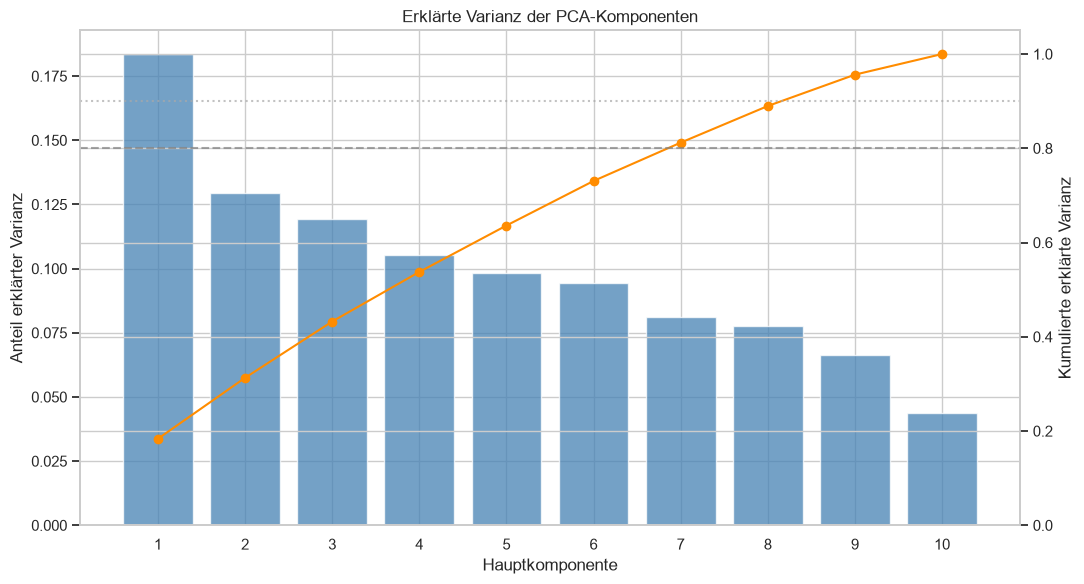

In [80]:
# Erklärte Varianz visualisieren.

fig, ax1 = plt.subplots(figsize=(11, 6))

component_numbers = np.arange(
    1,
    len(pca_full.explained_variance_ratio_) + 1
)


ax1.bar(
    component_numbers,
    pca_full.explained_variance_ratio_,
    color="steelblue",
    alpha=0.75,
    label="Einzelne erklärte Varianz"
)

ax1.set_xlabel("Hauptkomponente")
ax1.set_ylabel("Anteil erklärter Varianz")
ax1.set_xticks(component_numbers)


ax2 = ax1.twinx()

ax2.plot(
    component_numbers,
    np.cumsum(
        pca_full.explained_variance_ratio_
    ),
    color="darkorange",
    marker="o",
    label="Kumulierte erklärte Varianz"
)

ax2.axhline(
    0.80,
    color="grey",
    linestyle="--",
    alpha=0.7,
    label="80-%-Schwelle"
)

ax2.axhline(
    0.90,
    color="darkgrey",
    linestyle=":",
    alpha=0.7,
    label="90-%-Schwelle"
)

ax2.set_ylabel("Kumulierte erklärte Varianz")
ax2.set_ylim(0, 1.05)

plt.title("Erklärte Varianz der PCA-Komponenten")

fig.tight_layout()
plt.show()

In [81]:
# Benötigte Komponenten bestimmen

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

components_for_80_percent = (
    np.argmax(cumulative_variance >= 0.80) + 1
)

components_for_90_percent = (
    np.argmax(cumulative_variance >= 0.90) + 1
)

print(
    "Komponenten für mindestens 80 % erklärte Varianz:",
    components_for_80_percent
)

print(
    "Komponenten für mindestens 90 % erklärte Varianz:",
    components_for_90_percent
)

print(
    "Erklärte Varianz von PC1 und PC2:",
    round(cumulative_variance[1], 3)
)

Komponenten für mindestens 80 % erklärte Varianz: 7
Komponenten für mindestens 90 % erklärte Varianz: 9
Erklärte Varianz von PC1 und PC2: 0.313


In [82]:
# PCA-Datensatz für die Visualisierung erstellen.

pca_visualization = pd.DataFrame(
    x_pca_full[:, :2],
    columns=["PC1", "PC2"],
    index=x_cluster_scaled.index
)

pca_visualization["kmeans_cluster"] = (
    final_kmeans_labels
)

pca_visualization["segment"] = (
    pca_visualization["kmeans_cluster"]
    .map(kmeans_segment_mapping)
)

pca_visualization["dbscan_cluster"] = (
    dbscan_comparison_labels
)

display(pca_visualization.head())

,PC1,PC2,kmeans_cluster,segment,dbscan_cluster
0,0.993,-0.917,3,Multi-Person Travelers,0
1,-1.156,0.960,4,Active Longer-Stay Hotel Guests,0
2,1.506,1.463,4,Active Longer-Stay Hotel Guests,-1
3,-0.995,-2.696,1,Low-Conversion Browsers,-1
4,1.744,-0.467,5,Premium Short-Stay Package Travelers,-1


In [84]:
# Einfluss der Merkmale auf PC1 und PC2

pca_loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    index=x_cluster_scaled.columns,
    columns=["PC1_loading", "PC2_loading"]
)

display(
    pca_loadings
    .assign(
        absolute_PC1=lambda dataframe:
            dataframe["PC1_loading"].abs(),
        absolute_PC2=lambda dataframe:
            dataframe["PC2_loading"].abs()
    )
    .sort_values(
        ["absolute_PC1", "absolute_PC2"],
        ascending=False
    )
)

,PC1_loading,PC2_loading,absolute_PC1,absolute_PC2
package_booking_rate,0.595,0.110,0.595,0.110
booking_session_rate,0.491,0.344,0.491,0.344
checked_bags_per_seat,0.391,0.091,0.391,0.091
travel_product_balance,0.282,-0.587,0.282,0.587
mean_seats,0.231,-0.104,0.231,0.104
return_flight_rate,-0.214,-0.079,0.214,0.079
mean_hotel_nights,-0.199,0.662,0.199,0.662
extended_stay_booking_share,0.155,0.150,0.155,0.150
weighted_fare_per_seat_after_discount_usd,-0.103,-0.123,0.103,0.123
median_hotel_price_per_room_usd,0.008,-0.155,0.008,0.155


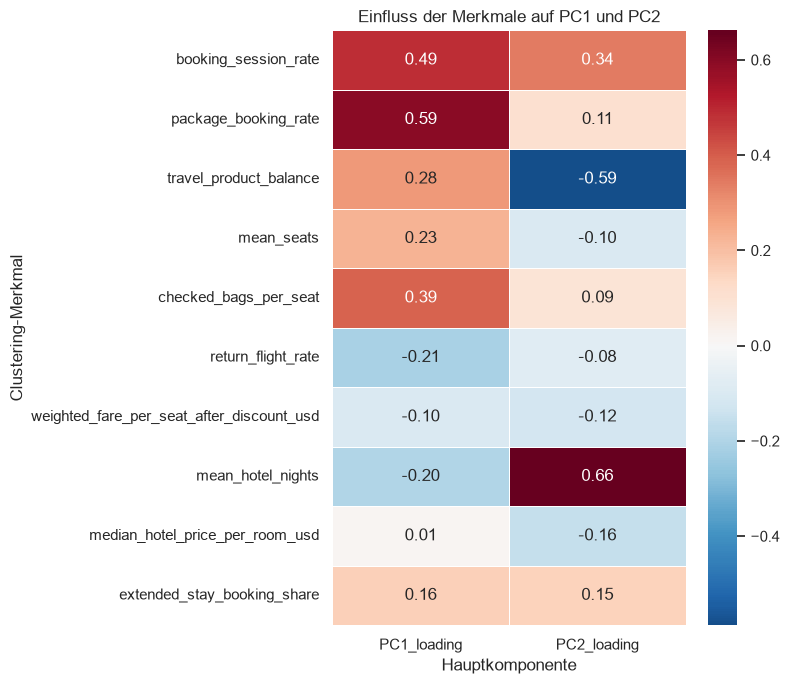

In [85]:
# Loadings visualisieren.

plt.figure(figsize=(8, 7))

sns.heatmap(
    pca_loadings,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Einfluss der Merkmale auf PC1 und PC2")
plt.xlabel("Hauptkomponente")
plt.ylabel("Clustering-Merkmal")

plt.tight_layout()
plt.show()

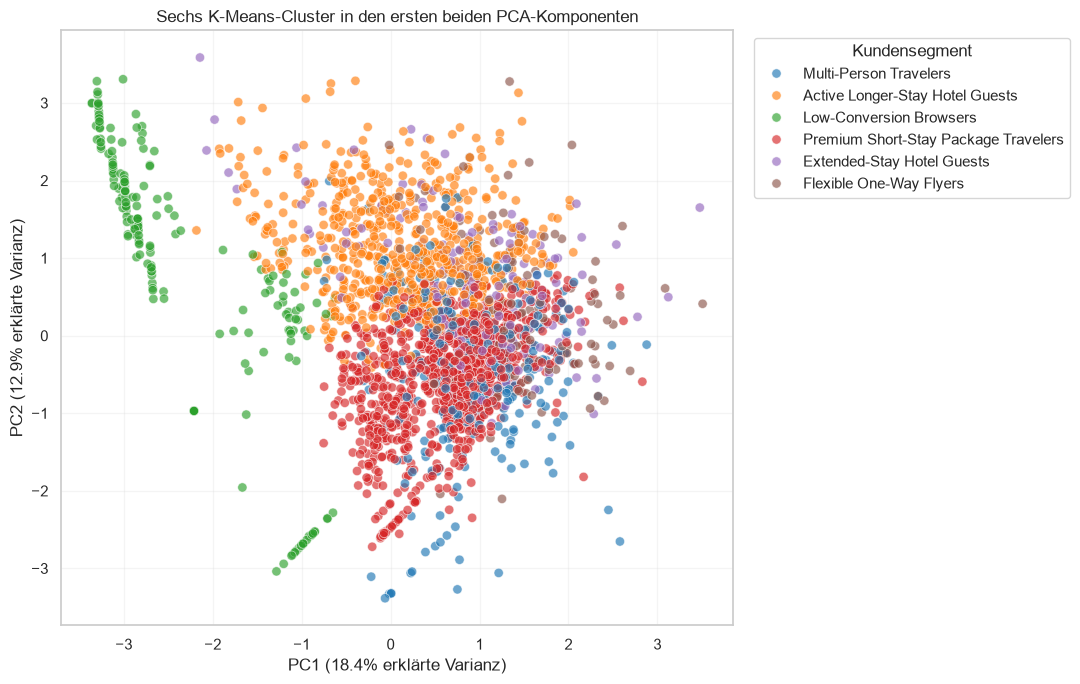

In [86]:
# K-Means-Cluster in der PCA-Darstellung visualisieren.

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=pca_visualization,
    x="PC1",
    y="PC2",
    hue="segment",
    palette="tab10",
    alpha=0.65,
    s=45
)

plt.title(
    "Sechs K-Means-Cluster in den ersten beiden PCA-Komponenten"
)

plt.xlabel(
    f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%} erklärte Varianz)"
)

plt.ylabel(
    f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%} erklärte Varianz)"
)

plt.legend(
    title="Kundensegment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

c:\Users\noraa\Desktop\Materialien\11 Mastery Project\traveltide-mastery-project\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


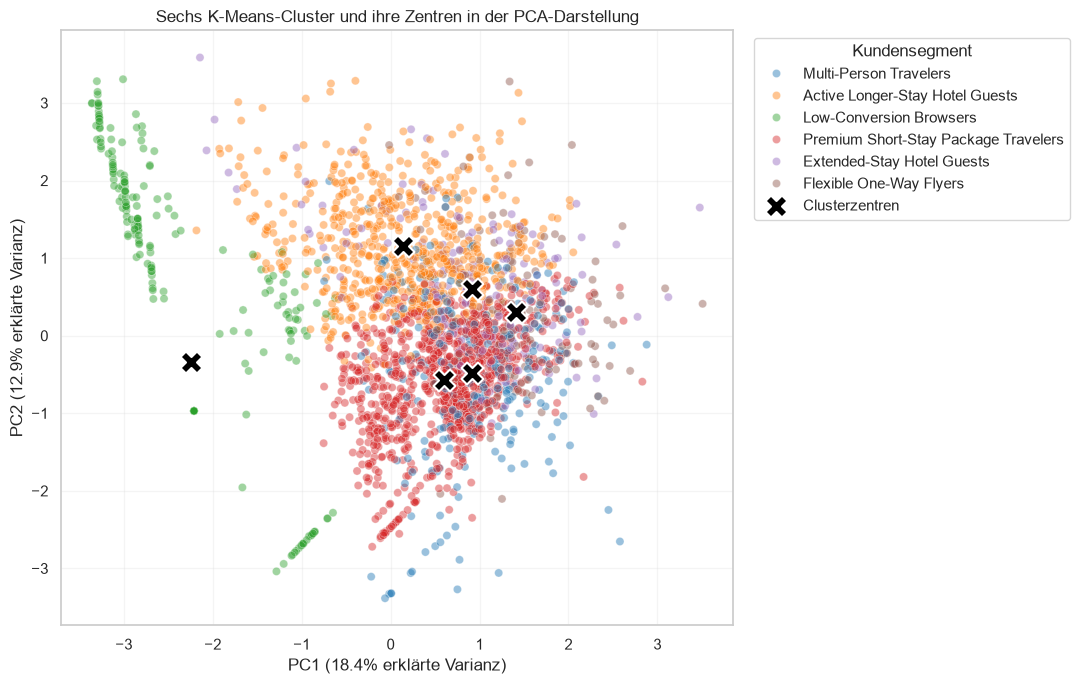

In [87]:
# Clusterzentren ergänzen.

kmeans_centers_pca = pca_full.transform(
    final_kmeans_model.cluster_centers_
)[:, :2]


plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=pca_visualization,
    x="PC1",
    y="PC2",
    hue="segment",
    palette="tab10",
    alpha=0.45,
    s=35
)

plt.scatter(
    kmeans_centers_pca[:, 0],
    kmeans_centers_pca[:, 1],
    marker="X",
    s=250,
    c="black",
    edgecolor="white",
    linewidth=1.5,
    label="Clusterzentren"
)

plt.title(
    "Sechs K-Means-Cluster und ihre Zentren in der PCA-Darstellung"
)

plt.xlabel(
    f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%} erklärte Varianz)"
)

plt.ylabel(
    f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%} erklärte Varianz)"
)

plt.legend(
    title="Kundensegment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

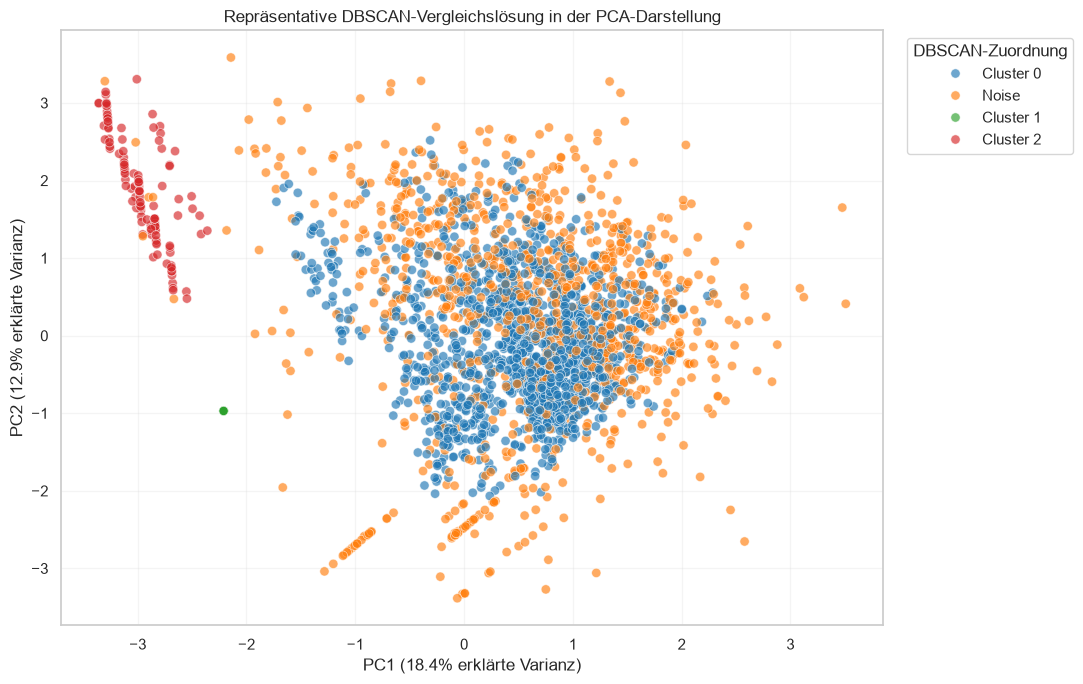

In [88]:
# DBSCAN zum Vergleich darstellen.

pca_visualization["dbscan_label"] = (
    pca_visualization["dbscan_cluster"]
    .apply(
        lambda cluster:
            "Noise"
            if cluster == -1
            else f"Cluster {cluster}"
    )
)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=pca_visualization,
    x="PC1",
    y="PC2",
    hue="dbscan_label",
    palette="tab10",
    alpha=0.65,
    s=45
)

plt.title(
    "Repräsentative DBSCAN-Vergleichslösung in der PCA-Darstellung"
)

plt.xlabel(
    f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%} erklärte Varianz)"
)

plt.ylabel(
    f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%} erklärte Varianz)"
)

plt.legend(
    title="DBSCAN-Zuordnung",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Ergebnis der PCA

Die ersten beiden Hauptkomponenten erklären zusammen rund 31,3 % der Gesamtvarianz. Für mindestens 80 % der erklärten Varianz werden sieben und für mindestens 90 % neun Hauptkomponenten benötigt. Die Kundenprofile besitzen somit weiterhin eine mehrdimensionale Struktur, die nicht vollständig in einer zweidimensionalen Darstellung abgebildet werden kann.

Die erste Hauptkomponente wird vor allem durch die Paketbuchungsrate, die Buchungssessionsrate und das Gepäck je Sitzplatz geprägt. Sie kann überwiegend als Dimension der Buchungs- und Paketaktivität interpretiert werden. Die zweite Hauptkomponente wird insbesondere durch die durchschnittliche Hotelaufenthaltsdauer und die Verteilung zwischen Flug- und Hotelverhalten bestimmt und bildet damit eine hotelbezogene Verhaltensdimension ab.

In der PCA-Darstellung zeigen die sechs K-Means-Cluster nachvollziehbare räumliche Tendenzen. Die Low-Conversion Browsers liegen überwiegend im Bereich geringer Buchungsaktivität, während die Active Longer-Stay Hotel Guests stärker in Richtung längerer Hotelaufenthalte ausgeprägt sind. Auch die übrigen Clusterzentren unterscheiden sich, obwohl sich die Kundenpunkte teilweise überschneiden.

Diese Überschneidungen sind angesichts des begrenzten Varianzanteils der ersten beiden Hauptkomponenten erwartbar. Die voneinander getrennten Clusterzentren und die zuvor festgestellte hohe Stabilität unterstützen dennoch die Sechs-Cluster-Lösung.

Die repräsentative DBSCAN-Darstellung zeigt dagegen ein dominierendes Hauptcluster, zwei kleinere Gruppen und zahlreiche Rauschpunkte. DBSCAN eignet sich daher eher zur Erkennung besonderer Kundenprofile als für eine vollständige operative Segmentierung.

Auf Grundlage der statistischen Kennzahlen, der Stabilitätsanalyse, der inhaltlichen Profile und der PCA-Visualisierung wird K-Means mit sechs Clustern als datenbasierte Ergänzung der regelbasierten Segmentierung ausgewählt.

## 8. Finale Kundensegmentierung

Für die finale Kundensegmentierung werden zwei Ansätze miteinander kombiniert.

Kunden mit besonders deutlich ausgeprägten Verhaltensmerkmalen wurden zunächst anhand fachlich begründeter Regeln segmentiert. Kunden, die keiner dieser Regeln entsprachen, wurden anschließend mithilfe von K-Means in sechs zusätzliche Verhaltensgruppen unterteilt.

Die finale Segmentierung umfasst damit:

- sechs regelbasierte Kundengruppen,
- sechs datenbasierte K-Means-Gruppen.

Jeder Kunde erhält genau ein primäres Segment. Die Zusammenführung erfolgt über die eindeutige `user_id`, sodass die ursprüngliche Kundentabelle vollständig erhalten bleibt.

In [89]:
# K-Means-Zuordnungen vorbereiten

kmeans_assignments = (
    unassigned_clustered[
        [
            "user_id",
            "kmeans_cluster",
            "segment"
        ]
    ]
    .rename(
        columns={
            "segment": "kmeans_segment"
        }
    )
    .copy()
)

print(
    "K-Means-Zuordnungen:",
    len(kmeans_assignments)
)

print(
    "Eindeutige Nutzer:",
    kmeans_assignments["user_id"].nunique()
)

print(
    "Doppelte Nutzer:",
    kmeans_assignments["user_id"].duplicated().sum()
)

K-Means-Zuordnungen: 2817
Eindeutige Nutzer: 2817
Doppelte Nutzer: 0


In [94]:
# Zusammenführung regelbasierte und datenbasierte Segmente über user_id.

final_customer_segments = (
    customer_segments
    .merge(
        kmeans_assignments,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

In [95]:
# Finale Segmentvariable erstellen.

final_customer_segments["final_segment"] = (
    final_customer_segments["rule_based_segment"]
    .astype("object")
)


kmeans_customer_mask = (
    final_customer_segments["kmeans_segment"]
    .notna()
)


final_customer_segments.loc[
    kmeans_customer_mask,
    "final_segment"
] = final_customer_segments.loc[
    kmeans_customer_mask,
    "kmeans_segment"
]

In [96]:
# Segmentierungsmethode zuordnen.

final_customer_segments["segmentation_method"] = (
    np.where(
        kmeans_customer_mask,
        "K-Means",
        "Rule-based"
    )
)

In [97]:
# Zusammenführung kontrollieren

print(
    "Zeilen in der finalen Tabelle:",
    len(final_customer_segments)
)

print(
    "Eindeutige Nutzer:",
    final_customer_segments["user_id"].nunique()
)

print(
    "Doppelte Nutzer:",
    final_customer_segments["user_id"].duplicated().sum()
)

print(
    "Fehlende finale Segmente:",
    final_customer_segments["final_segment"].isna().sum()
)

print(
    "Regelbasierte Zuordnungen:",
    (
        final_customer_segments["segmentation_method"]
        == "Rule-based"
    ).sum()
)

print(
    "K-Means-Zuordnungen:",
    (
        final_customer_segments["segmentation_method"]
        == "K-Means"
    ).sum()
)

Zeilen in der finalen Tabelle: 5752
Eindeutige Nutzer: 5752
Doppelte Nutzer: 0
Fehlende finale Segmente: 0
Regelbasierte Zuordnungen: 2935
K-Means-Zuordnungen: 2817


In [98]:
# Finale Segmentgrößen berechnen

final_segment_overview = (
    final_customer_segments
    .groupby(
        [
            "segmentation_method",
            "final_segment"
        ]
    )
    .size()
    .rename("customer_count")
    .reset_index()
)


final_segment_overview["customer_share"] = (
    final_segment_overview["customer_count"]
    / len(final_customer_segments)
)


final_segment_overview = (
    final_segment_overview
    .sort_values(
        "customer_count",
        ascending=False
    )
    .reset_index(drop=True)
)

display(final_segment_overview)

,segmentation_method,final_segment,customer_count,customer_share
0,K-Means,Premium Short-Stay Package Travelers,987,0.172
1,Rule-based,Discount-Responsive Travelers,868,0.151
2,Rule-based,Baggage-Intensive Flyers,789,0.137
3,K-Means,Active Longer-Stay Hotel Guests,647,0.112
4,K-Means,Low-Conversion Browsers,583,0.101
5,Rule-based,Long-Stay Hotel Guests,558,0.097
6,Rule-based,Cancellation-Experienced Travelers,330,0.057
7,K-Means,Multi-Person Travelers,282,0.049
8,Rule-based,High-Value Bookers,208,0.036
9,Rule-based,Family Travelers,182,0.032


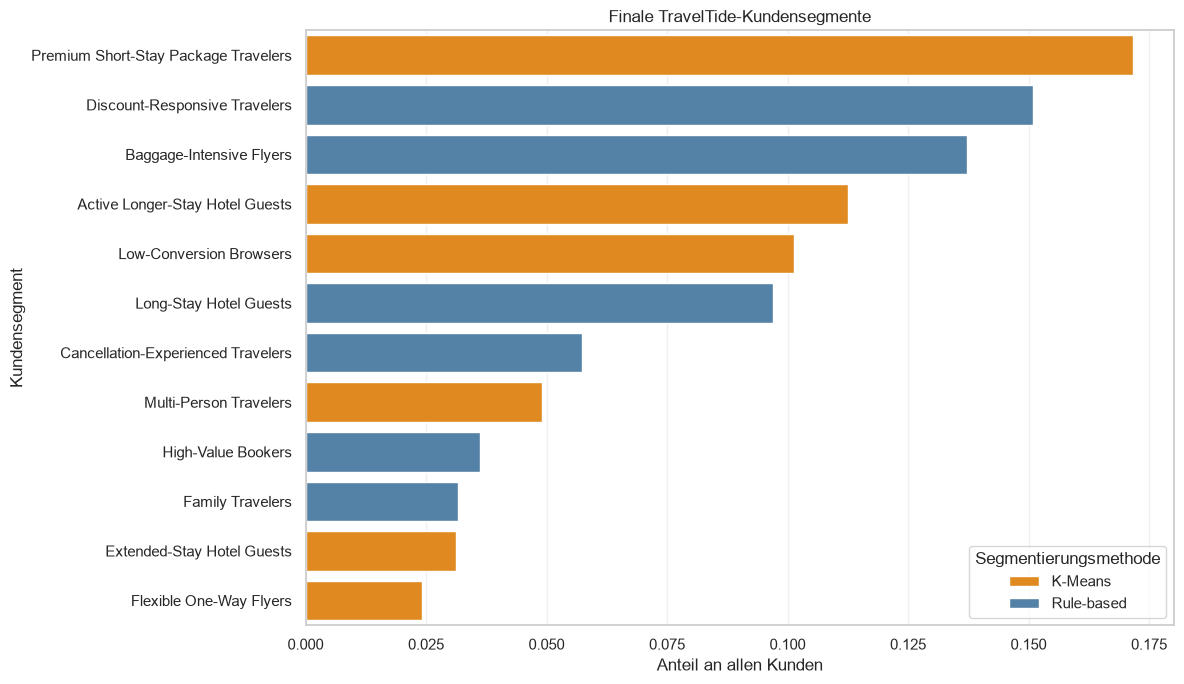

In [99]:
# Segmentgrößen visualisieren.

plt.figure(figsize=(12, 7))

sns.barplot(
    data=final_segment_overview,
    y="final_segment",
    x="customer_share",
    hue="segmentation_method",
    dodge=False,
    palette={
        "Rule-based": "steelblue",
        "K-Means": "darkorange"
    }
)

plt.title("Finale TravelTide-Kundensegmente")
plt.xlabel("Anteil an allen Kunden")
plt.ylabel("Kundensegment")
plt.legend(title="Segmentierungsmethode")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [100]:
# Stichprobe der finalen Zuordnung.

display(
    final_customer_segments[
        [
            "user_id",
            "rule_based_segment",
            "kmeans_cluster",
            "kmeans_segment",
            "final_segment",
            "segmentation_method"
        ]
    ]
    .sample(
        10,
        random_state=42
    )
)

,user_id,rule_based_segment,kmeans_cluster,kmeans_segment,final_segment,segmentation_method
2471,532622,Discount-Responsive Travelers,NaN,NaN,Discount-Responsive Travelers,Rule-based
5243,623142,Discount-Responsive Travelers,NaN,NaN,Discount-Responsive Travelers,Rule-based
3406,550460,Discount-Responsive Travelers,NaN,NaN,Discount-Responsive Travelers,Rule-based
4213,571084,Discount-Responsive Travelers,NaN,NaN,Discount-Responsive Travelers,Rule-based
3076,543952,Discount-Responsive Travelers,NaN,NaN,Discount-Responsive Travelers,Rule-based
4640,586701,Unassigned,4.000,Active Longer-Stay Hotel Guests,Active Longer-Stay Hotel Guests,K-Means
3592,555135,Discount-Responsive Travelers,NaN,NaN,Discount-Responsive Travelers,Rule-based
4284,573378,Unassigned,3.000,Multi-Person Travelers,Multi-Person Travelers,K-Means
1370,516273,Unassigned,5.000,Premium Short-Stay Package Travelers,Premium Short-Stay Package Travelers,K-Means
1163,513497,Unassigned,0.000,Extended-Stay Hotel Guests,Extended-Stay Hotel Guests,K-Means


### Ergebnis der finalen Kundensegmentierung

Die regelbasierte und die datenbasierte Segmentierung wurden über die eindeutige `user_id` zusammengeführt. Jeder der 5.752 Kunden wurde genau einem primären Segment zugeordnet.

Insgesamt wurden 2.935 Kunden anhand besonders deutlich ausgeprägter Verhaltensmerkmale regelbasiert segmentiert. Die übrigen 2.817 Kunden wurden mithilfe der ausgewählten K-Means-Lösung einer von sechs zusätzlichen Verhaltensgruppen zugeordnet.

Die finale Segmentierung umfasst damit zwölf Kundengruppen. Das größte Segment bilden die Premium Short-Stay Package Travelers mit rund 17 % aller Kunden. Es folgen die Discount-Responsive Travelers mit rund 15 % und die Baggage-Intensive Flyers mit rund 14 %. Die kleinsten Gruppen sind die Extended-Stay Hotel Guests und die Flexible One-Way Flyers mit rund 180 bzw. 140 Kunden.

Die Größenverteilung zeigt keine extrem kleinen Restgruppen und ermöglicht eine differenzierte, aber weiterhin nachvollziehbare Marketingsegmentierung. Dabei müssen die zwölf Kundensegmente nicht zwangsläufig zwölf unterschiedliche Rewards-Benefits erhalten. Mehrere Segmente können denselben Benefit bekommen, jedoch mit einer auf ihr jeweiliges Verhalten abgestimmten Kommunikation angesprochen werden.

## 9. Gesamtfazit der Kundensegmentierung

Für die Entwicklung des TravelTide-Rewards-Programms wurde ein hybrider
Segmentierungsansatz verwendet. Kunden mit besonders klar ausgeprägten
Verhaltensmerkmalen wurden zunächst anhand transparenter fachlicher Regeln
segmentiert. Dadurch konnten sechs Gruppen identifiziert werden:

- Family & Group Travelers
- Long-Stay Hotel Guests
- Baggage-Intensive Flyers
- Discount-Responsive Travelers
- Cancellation-Experienced Travelers
- High-Value Bookers

Von den insgesamt 5.752 Kunden wurden 2.935 Kunden einer dieser
regelbasierten Gruppen zugeordnet. Für die verbleibenden 2.817 Kunden wurde
eine datenbasierte Segmentierung durchgeführt.

Nach Merkmalsauswahl, Behandlung fehlender Werte, Transformation
rechtsschiefer Preismerkmale und Standardisierung wurden verschiedene
K-Means-Lösungen untersucht. Unter Berücksichtigung von Clusterqualität,
Stabilität, Größenverteilung, Interpretierbarkeit und operativer
Verwendbarkeit wurde eine Lösung mit vier Clustern gewählt:

- Flight Deal Travelers
- Hotel Deal Travelers
- Low-Conversion Browsers
- Regular Package Travelers

Die ausgewählte K-Means-Lösung erwies sich als sehr stabil und ergänzte die
regelbasierten Gruppen um vier verständliche Verhaltensmuster. DBSCAN wurde
als Vergleichsverfahren untersucht, erzeugte jedoch entweder ein
dominierendes Hauptcluster, zahlreiche Rauschpunkte oder sehr kleine
Sondergruppen. Für die vollständige operative Segmentierung war DBSCAN daher
weniger geeignet.

Die PCA bestätigte die mehrdimensionale Struktur der Kundendaten. Die ersten
beiden Hauptkomponenten erklärten zusammen rund 27,6 % der Gesamtvarianz und
verdeutlichten insbesondere Unterschiede in der Buchungsaktivität, der
Paketbuchung sowie im Flug- und Hotelverhalten. Die Visualisierung
unterstützte die inhaltliche Interpretation der K-Means-Cluster.

Durch die Kombination aus regelbasierter und datenbasierter Segmentierung
erhält jeder Kunde genau ein primäres Segment. Die finale Lösung umfasst zehn
Kundengruppen und verbindet fachlich nachvollziehbare Regeln mit
datenbasierten Verhaltensmustern.

Die segmentierte Kundentabelle bildet die Grundlage für die anschließende
Auswahl geeigneter Rewards-Benefits und segmentbezogener
Kommunikationsempfehlungen.

## 10. Export der segmentierten Kundentabelle

Abschließend wird die vollständige Kundentabelle einschließlich der finalen
Segmentzuordnung exportiert. Neben dem primären Kundensegment bleiben auch
die verwendete Segmentierungsmethode, die regelbasierte Zuordnung und die
technische K-Means-Zuordnung erhalten. Dadurch bleibt nachvollziehbar, wie
die jeweilige Segmententscheidung zustande gekommen ist.

Die exportierte Tabelle umfasst weiterhin alle 5.752 eindeutigen Kunden und
sämtliche für die weitere Analyse relevanten Kundenmerkmale. Sie bildet die
Datengrundlage für das folgende Notebook, in dem passende Rewards-Benefits
und segmentbezogene Marketingempfehlungen entwickelt werden.

Nach dem Export wird die Datei erneut eingelesen und hinsichtlich Zeilenzahl,
eindeutiger Nutzer, fehlender Segmentzuordnungen und Anzahl der finalen
Segmente kontrolliert.

In [101]:
# Finale Exporttabelle vorbereiten.

assignment_columns = [
    "user_id",
    "final_segment",
    "segmentation_method",
    "rule_based_segment",
    "kmeans_cluster",
    "kmeans_segment"
]

assignment_columns = [
    column
    for column in assignment_columns
    if column in final_customer_segments.columns
]

remaining_columns = [
    column
    for column in final_customer_segments.columns
    if column not in assignment_columns
]

final_customer_export = (
    final_customer_segments[
        assignment_columns
        + remaining_columns
    ]
    .copy()
)

In [102]:
# Exporttabelle kontrollieren.

print(
    "Zeilen:",
    len(final_customer_export)
)

print(
    "Eindeutige Nutzer:",
    final_customer_export["user_id"].nunique()
)

print(
    "Doppelte Nutzer:",
    final_customer_export["user_id"].duplicated().sum()
)

print(
    "Fehlende Segmente:",
    final_customer_export["final_segment"].isna().sum()
)

print(
    "Anzahl finaler Segmente:",
    final_customer_export["final_segment"].nunique()
)

display(final_customer_export.head())

Zeilen: 5752
Eindeutige Nutzer: 5752
Doppelte Nutzer: 0
Fehlende Segmente: 0
Anzahl finaler Segmente: 12


,user_id,final_segment,segmentation_method,rule_based_segment,kmeans_cluster,kmeans_segment,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age,customer_tenure_days,customer_tenure_months,session_count,mean_session_duration_minutes,median_session_duration_minutes,total_page_clicks,mean_page_clicks,low_click_session_rate,booking_session_count,flight_booking_session_count,hotel_booking_session_count,package_booking_session_count,cancellation_count,flight_discount_offer_count,hotel_discount_offer_count,mean_flight_discount_amount,mean_hotel_discount_amount,discounted_flight_booking_count,discounted_hotel_booking_count,booking_session_rate,cancellation_session_rate,package_booking_rate,flight_discount_conversion_rate,hotel_discount_conversion_rate,flight_booking_count,total_flight_value_before_discount_usd,total_flight_value_after_discount_usd,total_realized_flight_spend_usd,mean_flight_booking_value_after_discount_usd,total_seats,mean_seats,total_checked_bags,mean_checked_bags,mean_fare_per_seat_after_discount_usd,return_flight_rate,cancelled_flight_count,weighted_fare_per_seat_after_discount_usd,hotel_booking_count,total_hotel_value_before_discount_usd,mean_hotel_value_before_discount_usd,total_hotel_value_after_discount_usd,mean_hotel_value_after_discount_usd,total_realized_hotel_spend_usd,mean_completed_hotel_spend_usd,total_hotel_nights,mean_hotel_nights,total_rooms,mean_rooms,mean_hotel_price_per_room_usd,median_hotel_price_per_room_usd,unique_hotel_brands,unique_hotel_cities,extended_stay_booking_count,extended_stay_booking_share,cancelled_hotel_count,preferred_hotel_segment,preferred_hotel_city,hotel_price_tier_share_Low price,hotel_price_tier_share_Medium price,hotel_price_tier_share_High price,hotel_price_tier_share_Very high price,has_flight_booking,has_hotel_booking,has_travel_booking,checked_bags_per_seat,total_cancelled_bookings,historical_customer_value_usd,total_discount_offer_count,total_discounted_booking_count,booking_discount_rate,high_value_booker,family_traveler,long_stay_hotel_guest,discount_responsive_traveler,baggage_intensive_flyer,cancellation_experienced_traveler,matched_rule_count
0,23557,Long-Stay Hotel Guests,Rule-based,Long-Stay Hotel Guests,NaN,NaN,1958-12-08,F,True,False,usa,new york,LGA,40.777,-73.872,2021-07-22,64,736,24.179,8,1.277,1.158,82,10.250,0.000,2,0,2,0,0,0,2,NaN,0.175,0,1,0.250,0.000,0.000,NaN,0.500,0.000,0.000,0.000,0.000,NaN,0.000,NaN,0.000,NaN,NaN,NaN,0.000,NaN,2.000,"3,802.000","1,901.000","3,670.500","1,835.250","3,670.500","1,835.250",20.000,10.000,3.000,1.500,177.000,177.000,2.000,2.000,1.000,0.500,0.000,Economy,Calgary,0.500,0.000,0.000,0.500,False,True,True,0.000,0.000,"3,670.500",2,1,0.500,False,False,True,True,False,False,2
1,94883,Multi-Person Travelers,K-Means,Unassigned,3.000,Multi-Person Travelers,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,51,536,17.608,8,1.129,0.625,73,9.125,0.000,2,2,2,2,0,0,1,NaN,0.100,0,0,0.250,0.000,1.000,NaN,0.000,2.000,864.090,864.090,864.090,432.045,3.000,1.500,1.000,0.500,276.252,1.000,0.000,288.030,2.000,230.000,115.000,230.000,115.000,230.000,115.000,2.000,1.000,3.000,1.500,90.000,90.000,2.000,2.000,0.000,0.000,0.000,Luxury,Jacksonville,0.500,0.500,0.000,0.000,True,True,True,0.333,0.000,"1,094.090",1,0,0.000,False,False,False,False,False,False,0
2,101486,Active Longer-Stay Hotel Guests,K-Means,Unassigned,4.000,Active Longer-Stay Hotel Guests,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,50,526,17.280,8,2.038,2.433,131,16.375,0.000,2,1,2,1,0,2,0,0.075,NaN,0,0,0.250,0.000,0.500,0.000,NaN,1.000,189.910,189.910,189.910,189.910,1.000,1.000,0.000,0.000,189.910,1.000,0.000,189.910,2.000,"2,199.000","1,099.500","2,199.000","1,099.500","2,199.000","1,099.500",8.000,4.000,3.000,1.500,198.500,198.500,2.000,2.000,0.000,0.000,0.000,Luxury,Edmonton,0.000,0.500,0.000,0.500,True,True,True,0.000,0.000,"2,388.910",2,0,0.000,False,False,False,Fa

In [103]:
# CSV exportieren.

from pathlib import Path


output_directory = Path("../data/processed")

output_directory.mkdir(
    parents=True,
    exist_ok=True
)


segment_export_path = (
    output_directory
    / "traveltide_customer_segments.csv"
)


final_customer_export.to_csv(
    segment_export_path,
    index=False
)


print(
    "Datei exportiert nach:",
    segment_export_path.resolve()
)

Datei exportiert nach: C:\Users\noraa\Desktop\Materialien\11 Mastery Project\traveltide-mastery-project\data\processed\traveltide_customer_segments.csv


In [104]:
# Export überprüfen.

segment_export_check = pd.read_csv(
    segment_export_path
)

print(
    "Exportierte Zeilen:",
    len(segment_export_check)
)

print(
    "Exportierte Nutzer:",
    segment_export_check["user_id"].nunique()
)

print(
    "Fehlende finale Segmente:",
    segment_export_check["final_segment"].isna().sum()
)

print(
    "Finale Segmente:",
    segment_export_check["final_segment"].nunique()
)

Exportierte Zeilen: 5752
Exportierte Nutzer: 5752
Fehlende finale Segmente: 0
Finale Segmente: 12
